# Damped sinusoid

In [4]:
# Standard python imports
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.interpolate import interp1d
import configparser
from scipy.signal import windows
from scipy.linalg import toeplitz
from scipy.fft import fft, ifft
import os
import errno

# LVC-specific imports
import pyRing.waveform as wf
from pyRing.utils import *
from lalinference.imrtgr.nrutils import *
from pyRing.inject_signal import inject_ringdown_signal
from pyRing.utils import compute_SNR_FD, compute_SNR_TD, project_python_wrapper

from lalinference                import DetFrameToEquatorial, EquatorialToDetFrame
from lalinference.imrtgr.nrutils import bbh_final_mass_projected_spins, bbh_final_spin_projected_spins, bbh_Kerr_trunc_opts
import lal, lalsimulation as lalsim


import bilby
from bilby.core.utils import nfft
from bilby.gw.utils import optimal_snr_squared
from bilby.gw.detector.psd import PowerSpectralDensity
from bilby.core import utils

def damped_sinusoid(time, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
    waveform1 = np.zeros(len(time), dtype=complex)
    waveform2 = np.zeros(len(time), dtype=complex)

    A1 = A1 * 1e-19
    A2 = A2 * 1e-19
    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)

    tidx = time >= geocent_time

    waveform1[tidx] = A1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
    waveform2[tidx] = A2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

    total_waveform = waveform1 + waveform2

    plus = total_waveform.real
    cross = - total_waveform.imag

    return {"plus": plus, "cross": cross}

def damped_sinusoid_fdomain_Heaviside(frequency, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        A1 = A1 * 1e-19
        A2 = A2 * 1e-19

        d_positive_1 = (-1j / tau1) + (2 * (frequency + f1) * np.pi)
        d_negative_1 = (-1j / tau1) + (2 * (frequency - f1) * np.pi)
    
        d_positive_2 = (-1j / tau2) + (2 * (frequency + f2) * np.pi)
        d_negative_2 = (-1j / tau2) + (2 * (frequency - f2) * np.pi)
        
        plus = A1 * ((-1/tau1 - 1j*2*np.pi*frequency) * np.cos(phi1) + 2*np.pi*f1*np.sin(phi1)) / (d_positive_1 * d_negative_1) + A2 * ((-1/tau2 - 1j*2*np.pi*frequency) * np.cos(phi2) + 2*np.pi*f2*np.sin(phi2)) / (d_positive_2 * d_negative_2)
        cross = -A1 * (2*np.pi*f1*np.cos(phi1) + (1/tau1 + 1j*2*np.pi*frequency) * np.sin(phi1)) / (d_positive_1 * d_negative_1) - A2 * (2*np.pi*f2*np.cos(phi2) + (1/tau2 + 1j*2*np.pi*frequency) * np.sin(phi2)) / (d_positive_2 * d_negative_2)

        return {'plus': plus, 'cross': -cross}

def damped_sinusoid_tdomain_mirror(time, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
    waveform1 = np.zeros(len(time), dtype=complex)
    waveform2 = np.zeros(len(time), dtype=complex)

    A1 = A1 * 1e-19 / 2**0.5
    A2 = A2 * 1e-19 / 2**0.5
    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)

    waveform1 = A1 * np.exp(1j * (2*np.pi*f1 * (time - geocent_time)) + 1j * phi1) * np.exp(np.abs(time - geocent_time) * (-1 / tau1))
    waveform2 = A2 * np.exp(1j * (2*np.pi*f2 * (time - geocent_time)) + 1j * phi2) * np.exp(np.abs(time - geocent_time) * (-1 / tau2))

    total_waveform = waveform1 + waveform2

    plus = total_waveform.real
    cross = - total_waveform.imag

    return {"plus": plus, "cross": cross}

def damped_sinusoid_fdomain_mirror(frequency, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        A1 = A1 * 1e-19
        A2 = A2 * 1e-19

        d_positive_1 = (1 / tau1)**2 + (2 * (frequency + f1) * np.pi)**2
        d_negative_1 = (1 / tau1)**2 + (2 * (frequency - f1) * np.pi)**2
    
        d_positive_2 = (1 / tau2)**2 + (2 * (frequency + f2) * np.pi)**2
        d_negative_2 = (1 / tau2)**2 + (2 * (frequency - f2) * np.pi)**2
        
        plus = 1 / 2**0.5 * (A1 / tau1 * (np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1) + A2 / tau2 * (np.exp(-1j * phi2) / d_positive_2 + np.exp(1j * phi2) / d_negative_2))
        cross = 1 / 2**0.5 * (-1j) * (A1 / tau1 * (- np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1) + A2 / tau2 * (- np.exp(-1j * phi2) / d_positive_2 + np.exp(1j * phi2) / d_negative_2))

        return {'plus': plus, 'cross': cross}

def damped_sinusoid_one_mode_fdomain_mirror(frequency, A1, f1, tau1, phi1, geocent_time, A2, f2, tau2, phi2):
        A1 = A1 * 1e-19

        d_positive_1 = (1 / tau1)**2 + (2 * (frequency + f1) * np.pi)**2
        d_negative_1 = (1 / tau1)**2 + (2 * (frequency - f1) * np.pi)**2
    
        plus = 1 / 2**0.5 * (A1 / tau1 * (np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1))
        cross = 1 / 2**0.5 * (-1j) * (A1 / tau1 * (- np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1))

        return {'plus': plus, 'cross': cross}

def compute_covariance_matrix_from_psd(psd, srate, signal_duration):
    dt = 1.0 / srate
    noise_seglen = int(1 * srate)
    signal_seglen = int(signal_duration * srate)
    freqs_from_file, psd_from_file = psd[:,0], psd[:,1]

    f_min_psd = 20.5
    f_max_psd = 2038.0

    psd_from_file   = psd_from_file[  freqs_from_file > f_min_psd]
    freqs_from_file = freqs_from_file[freqs_from_file > f_min_psd]
    psd_from_file   = psd_from_file[  freqs_from_file < f_max_psd]
    freqs_from_file = freqs_from_file[freqs_from_file < f_max_psd]

    psd_from_file_interp           = interp1d(freqs_from_file, psd_from_file, fill_value='extrapolate', bounds_error=False)
    freqs_default                  = np.fft.rfftfreq(noise_seglen, d = dt)
    df_default                     = np.diff(freqs_default)[0]
    psd_interp                     = psd_from_file_interp(freqs_default)
    psd_interp                     = np.abs(psd_interp)

    ACF = 0.5*np.real(np.fft.irfft(psd_interp*df_default))*noise_seglen
    ACF_signal = ACF[:signal_seglen]
    Covariance_matrix_signal = toeplitz(ACF_signal)
    epsilon = 1e-9 * np.max(np.diag(Covariance_matrix_signal))
    Covariance_matrix_signal += epsilon * np.eye(signal_seglen)
    return Covariance_matrix_signal

def inject_pyring_waveform(config_file_bilby, config_file_pyring=None, plot_bilby_waveform=False):

    if config_file_pyring is not None:
        config_ini_pyring = configparser.ConfigParser()
        config_ini_pyring.read(config_file_pyring)
        if not os.path.exists(config_file_pyring):
            raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), config_file_pyring)
        config_injection_pyring = config_ini_pyring['Injection']
    
    config_ini_bilby = configparser.ConfigParser()
    config_ini_bilby.read(config_file_bilby)
    if not os.path.exists(config_file_bilby):
        raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), config_file_bilby)
    config_injection_bilby = config_ini_bilby['injection_parameters']
    
    config_setting = config_ini_bilby['setting']
    mode_number = config_setting['mode_number']

    srate   = 4096
    # signal_duration = 410 / srate
    signal_duration = 1.0
    pre_trigger_duration = signal_duration / 2.0
    trigger_time = float(config_injection_bilby['geocent_time'])
    times   = np.linspace(trigger_time-pre_trigger_duration, trigger_time+signal_duration-pre_trigger_duration, int(srate*signal_duration))

    A = float(config_injection_bilby['A']) * 1e-20  # Convert to strain unit
    alpha = float(config_injection_bilby['alpha'])
    w1 = (2 * np.pi * float(config_injection_bilby['f1']) + 1j / float(config_injection_bilby['tau1']))
    w2 = (2 * np.pi * float(config_injection_bilby['f2']) + 1j / float(config_injection_bilby['tau2']))
    delta_w = w2 - w1
    A1_complex = A / delta_w
    A1 = np.abs(A1_complex) / 1e-20
    phi1_from_amp = np.angle(A1_complex)
    phi1 = float(config_injection_bilby['phi1']) + phi1_from_amp
    A2_complex = - A * (1 + alpha * delta_w) / delta_w
    A2 = np.abs(A2_complex) / 1e-20
    phi2_from_amp = np.angle(A2_complex)
    phi2 = float(config_injection_bilby['phi2']) + phi2_from_amp

    bilby.core.utils.logger.info('A1 : {} * 1e-20'.format(A1))
    bilby.core.utils.logger.info('A2 : {} * 1e-20'.format(A2))
    bilby.core.utils.logger.info('alpha : {}'.format(alpha))
    bilby.core.utils.logger.info('w1 : {}'.format(w1))
    bilby.core.utils.logger.info('w2 : {}'.format(w2))
    bilby.core.utils.logger.info('delta_w : {}'.format(delta_w))
    bilby.core.utils.logger.info('delta_w * alpha : {}'.format(delta_w * alpha))
    bilby.core.utils.logger.info('phi1 : {}'.format(phi1))
    bilby.core.utils.logger.info('phi2 : {}'.format(phi2))


    if config_file_pyring is None:
        DS_parameters = {'A'   : {'t': [A1*1e-20, A2*1e-20]},
                     'f'   : {'t': [float(config_injection_bilby['f1']), float(config_injection_bilby['f2'])]},
                     'tau' : {'t': [float(config_injection_bilby['tau1']), float(config_injection_bilby['tau2'])]},
                     'phi' : {'t': [phi1, phi2]},
                     'psi' : float(config_injection_bilby['psi']),
                     'ra'  : float(config_injection_bilby['ra']),
                     'dec' : float(config_injection_bilby['dec']),
                     't'   : {'t': [float(config_injection_bilby['geocent_time']), float(config_injection_bilby['geocent_time'])]},
                     }
    else:
        if not 'A_t_1' in config_injection_pyring.keys():
            DS_parameters = {'A'   : {'t': [float(config_injection_pyring['A_t_0'])]},
                             'f'   : {'t': [float(config_injection_pyring['f_t_0'])]},
                             'tau' : {'t': [float(config_injection_pyring['tau_t_0'])]},
                             'phi' : {'t': [float(config_injection_pyring['phi_t_0'])]},
                             'psi' : float(config_injection_pyring['psi']),
                             'ra'  : float(config_injection_pyring['ra']),
                             'dec' : float(config_injection_pyring['dec']),
                             't'   : {'t': [float(config_injection_pyring['t_t_0'])]},
                             }
        else:
            # 't' means tensor modes
            DS_parameters = {'A'   : {'t': [float(config_injection_pyring['A_t_0']), float(config_injection_pyring['A_t_1'])]},
                             'f'   : {'t': [float(config_injection_pyring['f_t_0']), float(config_injection_pyring['f_t_1'])]},
                             'tau' : {'t': [float(config_injection_pyring['tau_t_0']), float(config_injection_pyring['tau_t_1'])]},
                             'phi' : {'t': [float(config_injection_pyring['phi_t_0']), float(config_injection_pyring['phi_t_1'])]},
                             'psi' : float(config_injection_pyring['psi']),
                             'ra'  : float(config_injection_pyring['ra']),
                             'dec' : float(config_injection_pyring['dec']),
                             't'   : {'t': [float(config_injection_pyring['t_t_0']), float(config_injection_pyring['t_t_1'])]},
                             }
    print('--- Injection Damped Sinusoid Parameters ---')
    print('[Injection]')
    for key in DS_parameters.keys():
        if isinstance(DS_parameters[key], dict):
            for mode in DS_parameters[key].keys():
                val_list = np.array(DS_parameters[key][mode])
                for num, val in enumerate(val_list):
                    print(f"{key}_{mode}_{num} = {val}")
        else:
            print(f"{key} = {DS_parameters[key]}")
    print('-------------------------------------------')
    DS_model = wf.Damped_sinusoids(DS_parameters['A']  ,
                                   DS_parameters['f']  ,
                                   DS_parameters['tau'],
                                   DS_parameters['phi'],
                                   DS_parameters['t'],
                                   )

    # Unpack the waveform and ignore vector and scalar modes.
    _, _, _, hp_DS, hc_DS = DS_model.waveform(times)

    if plot_bilby_waveform:
        if mode_number == 'one_mode':
            A2 = 0.0
        injection_parameters_bilby = dict(
                                    A1 = A1 * 1e-1,
                                    A2 = A2 * 1e-1,
                                    # A2 = A2 * 0,
                                    f1 = float(config_injection_bilby['f1']),
                                    # f1 = float(config_injection['f1']) + 50,
                                    f2 = float(config_injection_bilby['f2']),
                                    # deltaf = float(config_injection['f2']) - float(config_injection['f1']),
                                    tau1 = float(config_injection_bilby['tau1']),
                                    # tau1 = float(config_injection['tau1']) + 0.003,
                                    tau2 = float(config_injection_bilby['tau2']),
                                    phi1 = phi1,
                                    phi2 = phi2,
                                    ra = float(config_injection_bilby['ra']),
                                    dec = float(config_injection_bilby['dec']),
                                    psi = float(config_injection_bilby['psi']),
                                    geocent_time = float(config_injection_bilby['geocent_time']),
                                    )
        waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                        duration = signal_duration,
                                        sampling_frequency = srate,
                                        time_domain_source_model = damped_sinusoid,
                                        # time_domain_source_model = damped_sinusoid_tdomain_mirror,
                                        # frequency_domain_source_model= damped_sinusoid_fdomain_Heaviside,
                                        # frequency_domain_source_model = damped_sinusoid_one_mode_fdomain_mirror,
                                        # frequency_domain_source_model = damped_sinusoid_fdomain_mirror,
                                        start_time = trigger_time - pre_trigger_duration,
                                        )

    plt.style.use('~/research/my_plot_style.style')
    # plt.title(r'$\mathrm{Damped \, sinusoids}$')
    if plot_bilby_waveform:
        ht_bilby = waveform_generator.time_domain_strain(injection_parameters_bilby)

        plt.figure()
        plt.plot(times, hp_DS, label=r'$h_{+}$', linestyle='-')
        plt.plot(times, ht_bilby['plus'], label=r'$h_{+}$ (bilby)', linestyle=':')
        plt.xlabel(r'$\mathrm{t \, [s]}$')
        plt.ylabel(r'$\mathrm{Strain}$')
        plt.xlim(-0.01, 0.05)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure()        
        plt.plot(times, hc_DS, label=r'$h_{\times}$', linestyle='-')
        plt.plot(times, ht_bilby['cross'], label=r'$h_{\times}$ (bilby)', linestyle=':')
        plt.xlabel(r'$\mathrm{t \, [s]}$')
        plt.ylabel(r'$\mathrm{Strain}$')
        plt.xlim(-0.01, 0.05)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()
    
    else:
        plt.figure()
        plt.plot(times, hp_DS, label=r'$\mathrm{h}_{+}$', linestyle='-')
        plt.plot(times, hc_DS, label=r'$\mathrm{h}_{\times}$', linestyle='-')
        plt.xlabel(r'$\mathrm{t \, [s]}$')
        plt.ylabel(r'$\mathrm{Strain}$')
        plt.xlim(-0.01, 0.05)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

    detectors = ['H1', 'L1', 'V1']

    plt.figure()
    # plt.title(r'$\mathrm{Injected \, Damped \, sinusoids}$')
    detector_wave_dicts = {}
    for detector in detectors:
        kwargs = {
            'injection-approximant' : 'Damped-sinusoids',
            'injection-parameters' : DS_parameters,
            'ref-det' : detector,
            'sky-frame' : 'equatorial',
            'injection-scaling' : 1.0,
        }
        wave, time_axis_waveform = inject_ringdown_signal(times=times, triggertime=trigger_time, ifo=detector, print_output=True, **kwargs)
        plt.plot(time_axis_waveform, wave, linestyle='solid', alpha=0.7, label=detector)
        detector_wave_dicts[detector] = {'waveform': wave, 'time_axis': time_axis_waveform}
    plt.xlabel(r'$\mathrm{t \, [s]}$')
    plt.ylabel(r'$\mathrm{Strain}$')
    plt.xlim(-0.01, 0.05)
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

    """calculate frequency domain strain"""
    ifos = bilby.gw.detector.InterferometerList(detectors)
    h_plus_fdomain, frequency_array = nfft(time_domain_strain=hp_DS, sampling_frequency=srate)
    h_cross_fdomain, frequency_array = nfft(time_domain_strain=hc_DS, sampling_frequency=srate)
    print(frequency_array.shape, h_plus_fdomain.shape, h_cross_fdomain.shape)

    if plot_bilby_waveform:
        hf_bilby = waveform_generator.frequency_domain_strain(injection_parameters_bilby)

        plt.figure()
        plt.plot(frequency_array, np.abs(h_plus_fdomain), label=r'$|h_{+}|$', linestyle='-')
        plt.plot(frequency_array, np.abs(hf_bilby['plus']), label=r'$|h_{+}|$ (bilby)', linestyle=':')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure()
        plt.plot(frequency_array, np.abs(h_cross_fdomain), label=r'$|h_{\times}|$', linestyle='-')
        plt.plot(frequency_array, np.abs(hf_bilby['cross']), label=r'$|h_{\times}|$ (bilby)', linestyle=':')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

        # plt.figure()
        # plt.plot(frequency_array, np.real(h_plus_fdomain), label=r'Re[$h_{+}$]', linestyle='-')
        # plt.plot(frequency_array, np.real(hf_bilby['plus']), label=r'Re[$h_{+}$] (bilby)', linestyle=':')
        # plt.xlim(10, 1000)
        # plt.xscale('log')
        # plt.xlabel('Frequency [Hz]')
        # plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        # plt.legend(loc='best')
        # plt.grid(alpha=0.3)
        # plt.show()

        # plt.figure()
        # plt.plot(frequency_array, np.real(h_cross_fdomain), label=r'Re[$h_{\times}$]', linestyle='-')
        # plt.plot(frequency_array, np.real(hf_bilby['cross']), label=r'Re[$h_{\times}$] (bilby)', linestyle=':')
        # plt.xlim(10, 1000)
        # plt.xscale('log')
        # plt.xlabel('Frequency [Hz]')
        # plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        # plt.legend(loc='best')
        # plt.grid(alpha=0.3)
        # plt.show()

    else:
        plt.figure()
        plt.plot(frequency_array, np.abs(h_plus_fdomain), label=r'$|h_{+}|$', color='crimson', linestyle='dashed')
        plt.plot(frequency_array, np.abs(h_cross_fdomain), label=r'$|h_{\times}|$', color='royalblue', linestyle='solid')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()
    
    """calculate frequency domain response and SNR"""
    for ifo in ifos:
        ifo.frequency_array = frequency_array
        ifo.minimum_frequency = 20.0
        ifo.maximum_frequency = 512
    

    psd_ligo = './asd_files/aLIGO_O4_high_psd.txt'
    psd_virgo = './asd_files/AdV_psd.txt'

    psd = {}
    psd['H1'] = np.loadtxt(psd_ligo)
    psd['L1'] = np.loadtxt(psd_ligo)
    psd['V1'] = np.loadtxt(psd_virgo)

    DS_parameters['geocent_time'] = float(config_injection_bilby['geocent_time'])

    SNR_pyring = []
    ht_dict_pyring = {}
    for name, ifo in zip(detectors, ifos):
        
        detector = lal.cached_detector_by_prefix[ifo.name]
        ref_det    = lal.cached_detector_by_prefix['H1']
        psi        = DS_parameters['psi']
        ra, dec    = DS_parameters['ra'], DS_parameters['dec']
        tM_gps     = lal.LIGOTimeGPS(float(DS_parameters['geocent_time']))
        time_delay = lal.ArrivalTimeDiff(detector.location, ref_det.location, ra, dec, tM_gps)

        ht_det = project_python_wrapper(hs=0,
                                        hvx=0, hvy=0,
                                        hp=hp_DS,
                                        hc=hc_DS,
                                        detector=detector,
                                        ra=DS_parameters['ra'],
                                        dec=DS_parameters['dec'],
                                        psi=DS_parameters['psi'],
                                        tgps=DS_parameters['geocent_time']
                                        )
        
        f_min_bp = 20.5
        f_max_bp = 2038.0
        bb, ab = butter(4, [f_min_bp / (srate / 2.), f_max_bp / (srate / 2.)], btype='band')
        
        ht_det_filtered = filtfilt(bb, ab, ht_det)
        ht_dict_pyring[ifo.name] = ht_det_filtered

        CM = compute_covariance_matrix_from_psd(psd[ifo.name], srate, signal_duration)
        inverse_CM = np.linalg.inv(CM)
        SNR = compute_SNR_TD(data=ht_det_filtered, template=ht_det_filtered, weights=inverse_CM)
        SNR_pyring.append(SNR)

    network_SNR = np.sqrt(np.sum(np.array(SNR_pyring)**2.))
    print('--------------------------------')
    print('SNR pyring: {}'.format(SNR_pyring))
    print('network SNR pyring: {}'.format(network_SNR))
    print('--------------------------------')

    # should be fd waveform for pyring using fft
    detector_wave_fdomain_dicts = {}
    for name, ifo in zip(detectors, ifos):
        hf_det, frequency_array = nfft(time_domain_strain=ht_dict_pyring[ifo.name], sampling_frequency=srate)
        detector_wave_fdomain_dicts[ifo.name] = {'waveform': hf_det, 'frequency_array': frequency_array}
        
    if plot_bilby_waveform:
        ifos_bilby = bilby.gw.detector.InterferometerList(detectors)
        ifos_bilby.set_strain_data_from_zero_noise(
                               sampling_frequency = srate,
                               duration = signal_duration,
                               start_time = trigger_time - pre_trigger_duration,
                               )
        for ifo_bilby, ifo in zip(ifos_bilby, ifos):
            ifo_bilby.minimum_frequency = ifo.minimum_frequency
            ifo_bilby.maximum_frequency = ifo.maximum_frequency

        ifos_bilby.inject_signal(
            waveform_generator = waveform_generator,
            parameters = injection_parameters_bilby,
            raise_error=False,
        )
        SNR_bilby = []
        for num, ifo in enumerate(ifos_bilby):
            hf_det_bilby = ifo.get_detector_response(waveform_generator.frequency_domain_strain(injection_parameters_bilby), injection_parameters_bilby)
            SNR_bilby.append(np.sqrt(np.real(ifo.optimal_snr_squared(hf_det_bilby))))
    network_SNR_bilby = np.sqrt(np.sum(np.array(SNR_bilby)**2.))
    print('--------------------------------')
    print('SNR: bilby {}'.format(SNR_bilby))
    print('network SNR: {}'.format(network_SNR_bilby))
    print('--------------------------------')
    
    if plot_bilby_waveform:
        plt.figure()
        for ifo, ifo_bilby in zip(ifos, ifos_bilby):
            plt.plot(ifo.frequency_array, np.abs(detector_wave_fdomain_dicts[ifo.name]['waveform']), label=ifo.name)
            plt.plot(ifo_bilby.frequency_array, np.abs(ifo_bilby.frequency_domain_strain), linestyle=':', label=ifo.name + ' (bilby)')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\sqrt{\mathrm{Hz}}]$')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
    else:
        plt.figure()
        for ifo in ifos:
            plt.plot(detector_wave_fdomain_dicts[ifo.name]['frequency_array'], 2*detector_wave_fdomain_dicts[ifo.name]['frequency_array']**0.5*np.abs(detector_wave_fdomain_dicts[ifo.name]['waveform']), label=ifo.name)
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\sqrt{\mathrm{Hz}}]$')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # --- デバッグ用コード追加 ---
    print("\n--- Antenna Pattern Check ---")
    gps_time = float(DS_parameters['geocent_time'])
    ra = DS_parameters['ra']
    dec = DS_parameters['dec']
    psi = DS_parameters['psi']
    for name, ifo in zip(detectors, ifos):
        # Bilbyの計算値
        fp_bilby, fc_bilby = ifo.antenna_response(ra, dec, gps_time, psi, mode='plus'), \
                             ifo.antenna_response(ra, dec, gps_time, psi, mode='cross')
    
        # 簡易的なLAL計算（project_python_wrapperの内部動作確認用）
        # 注: project_python_wrapperがGMSTを内部でどう扱っているかに依存します
        det_lal = lal.cached_detector_by_prefix[name]
        gmst = lal.GreenwichMeanSiderealTime(lal.LIGOTimeGPS(gps_time))
        fp_lal, fc_lal = lal.ComputeDetAMResponse(det_lal.response, ra, dec, psi, gmst)
    
        print(f"[{name}]")
        print(f"  Bilby : F+={fp_bilby:.4f}, Fx={fc_bilby:.4f}")
        print(f"  LAL   : F+={fp_lal:.4f}, Fx={fc_lal:.4f}")

17:13 bilby INFO    : A1 : 2.281200654005359 * 1e-20
17:13 bilby INFO    : A2 : 2.193576170046821 * 1e-20
17:13 bilby INFO    : alpha : 0.00029552945685847607
17:13 bilby INFO    : w1 : (1264.4143462793452+301.02689574732483j)
17:13 bilby INFO    : w2 : (1134.4389320257144+301.02689574732483j)
17:13 bilby INFO    : delta_w : (-129.9754142536308+0j)
17:13 bilby INFO    : delta_w * alpha : (-0.03841156357933093+0j)
17:13 bilby INFO    : phi1 : -3.141592653589793
17:13 bilby INFO    : phi2 : 0.0
17:13 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1.0, sampling_frequency=4096, start_time=-0.5, frequency_domain_source_model=None, time_domain_source_model=__main__.damped_sinusoid, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={})


--- Injection Damped Sinusoid Parameters ---
[Injection]
A_t_0 = 2.2812006540053588e-20
A_t_1 = 2.1935761700468206e-20
f_t_0 = 201.23779332666524
f_t_1 = 180.55156366778309
tau_t_0 = 0.0033219623034593474
tau_t_1 = 0.0033219623034593474
phi_t_0 = -3.141592653589793
phi_t_1 = 0.0
psi = 0.0
ra = 0.0
dec = 0.0
t_t_0 = 0.0
t_t_1 = 0.0
-------------------------------------------


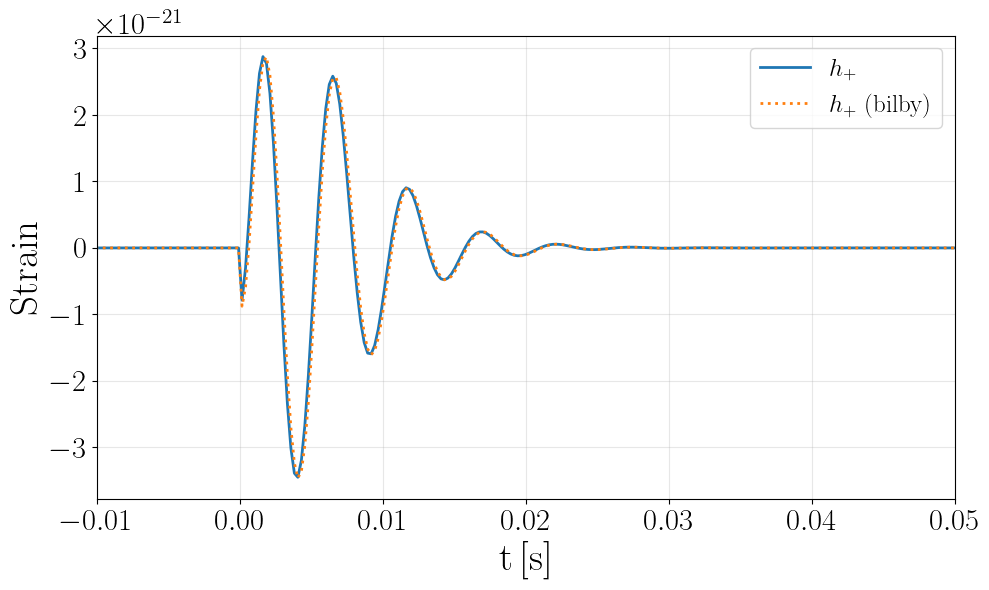

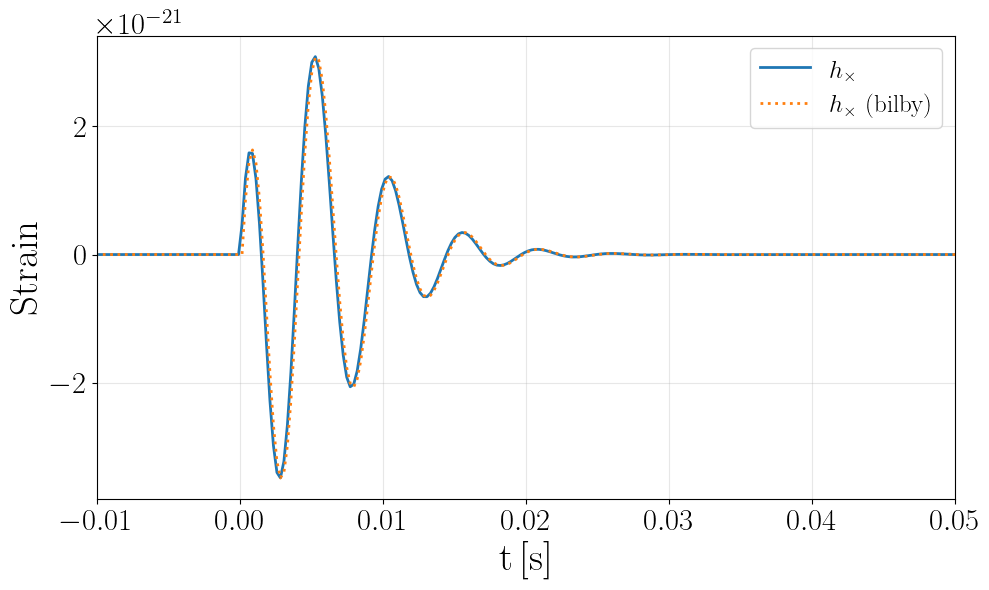

* Injecting the `Damped-sinusoids` waveform model in the H1 detector.
* Injecting the `Damped-sinusoids` waveform model in the L1 detector.
* Injecting the `Damped-sinusoids` waveform model in the V1 detector.


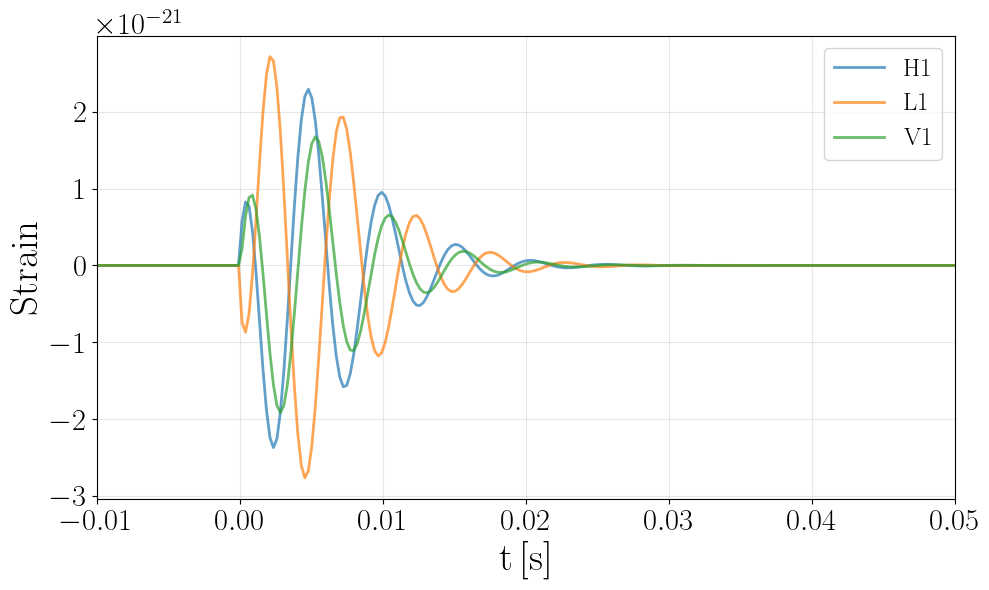

(2049,) (2049,) (2049,)


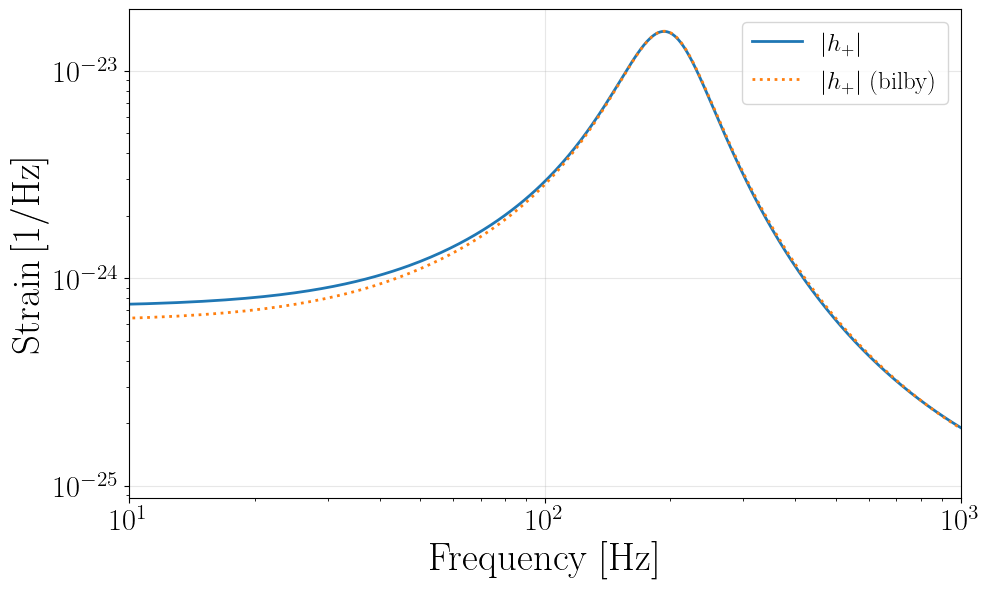

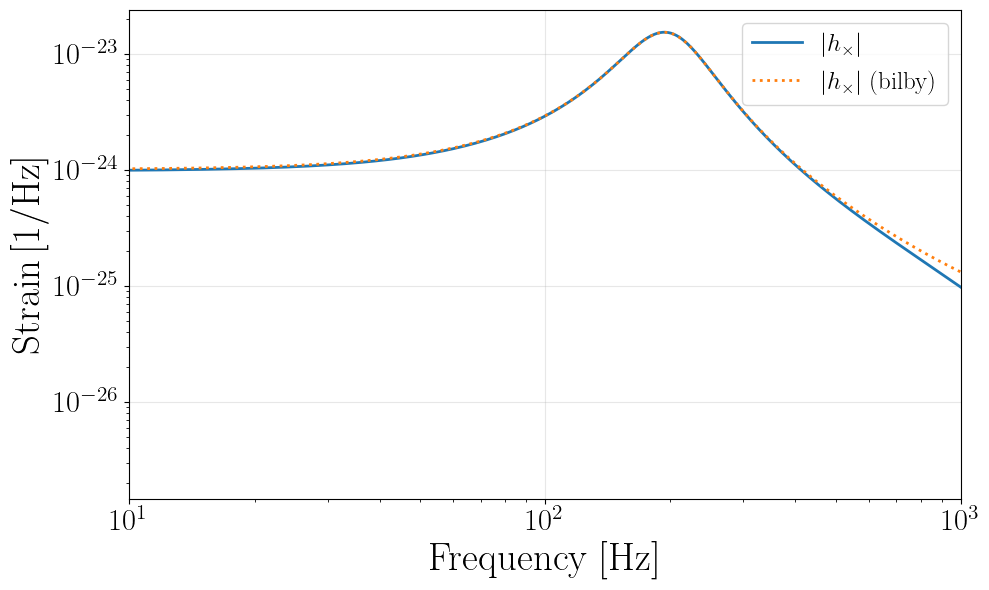

17:13 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
17:13 bilby INFO    : Generation of spin parameters failed with message 'spin_1z'
17:13 bilby INFO    : Generation of source frame parameters failed with message 'luminosity_distance'
17:13 bilby INFO    : Injected signal in H1:
17:13 bilby INFO    :   optimal SNR = 59.56
17:13 bilby INFO    :   matched filter SNR = 59.56-0.00j
17:13 bilby INFO    :   A1 = 0.2281200654005359
17:13 bilby INFO    :   A2 = 0.2193576170046821
17:13 bilby INFO    :   f1 = 201.23779332666524
17:13 bilby INFO    :   f2 = 180.55156366778309
17:13 bilby INFO    :   tau1 = 0.0033219623034593474
17:13 bilby INFO    :   tau2 = 0.0033219623034593474
17:13 bilby INFO    :   phi1 = -3.141592653589793
17:13 bilby INFO    :   phi2 = 0.0
17:13 bilby INFO    :   ra = 0.0
17:13 bilby INFO    :   dec = 0.0
17:13 bilby INFO    :   psi = 0.0
17:13 bilby INFO    :   geocent_time = 0.0
17:13 bilby INFO    : Generation of mass parameters failed wit

--------------------------------
SNR pyring: [59.57327841620493, 70.60596093560913, 38.46355513964473]
network SNR pyring: 100.06808829430051
--------------------------------
--------------------------------
SNR: bilby [59.55835049301124, 70.6281192872069, 38.44223681072555]
network SNR: 100.0666473831726
--------------------------------


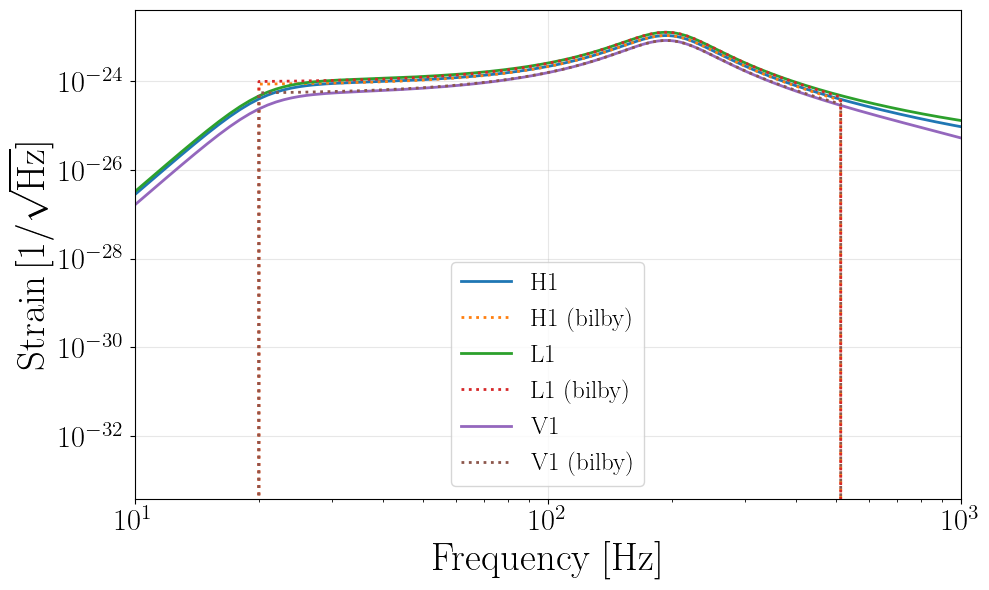


--- Antenna Pattern Check ---
[H1]
  Bilby : F+=-0.3814, Fx=0.5945
  LAL   : F+=-0.3814, Fx=0.5945
[L1]
  Bilby : F+=0.6109, Fx=-0.5707
  LAL   : F+=0.6109, Fx=-0.5707
[V1]
  Bilby : F+=0.0439, Fx=0.5454
  LAL   : F+=0.0439, Fx=0.5454


In [5]:
# label = 'shiftIm_to_220_dw0.1w1_snr100_DSparam'
# label = 'shiftIm_to_220_dw0.01w1_snr100_DSparam'
# label = 'shiftIm_to_220_dw0.001w1_snr100_DSparam'
label = 'shiftRe_to_220_dw0.1w1_snr100_DSparam'
# label = 'shiftRe_to_220_dw0.01w1_snr100_DSparam'
# label = 'shiftRe_to_220_dw0.001w1_snr100_DSparam'

config_file_bilby = f'./run_bilby/config/{label}_Mirror.ini'
config_file_pyring = f'./run_pyring/config/pyring_{label}.ini'
    
inject_pyring_waveform(config_file_bilby=config_file_bilby, config_file_pyring=config_file_pyring, plot_bilby_waveform=True)
# inject_pyring_waveform(config_file_bilby=config_file_bilby, config_file_pyring=None, plot_bilby_waveform=True)

# toy_model_of_two_QNMs_real_amp

In [9]:
# Standard python imports
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.interpolate import interp1d
import configparser
from scipy.signal import windows
from scipy.linalg import toeplitz
from scipy.fft import fft, ifft
import os
import errno

# LVC-specific imports
import pyRing.waveform as wf
from pyRing.utils import *
from lalinference.imrtgr.nrutils import *
from pyRing.inject_signal import inject_ringdown_signal
from pyRing.utils import compute_SNR_FD, compute_SNR_TD, project_python_wrapper

from lalinference                import DetFrameToEquatorial, EquatorialToDetFrame
from lalinference.imrtgr.nrutils import bbh_final_mass_projected_spins, bbh_final_spin_projected_spins, bbh_Kerr_trunc_opts
import lal, lalsimulation as lalsim


import bilby
from bilby.core.utils import nfft
from bilby.gw.utils import optimal_snr_squared
from bilby.gw.detector.psd import PowerSpectralDensity
from bilby.core import utils

def toy_model_of_two_QNMs_real_amp(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-17

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1
    
        tidx = time >= geocent_time

        real_amp_1 = np.abs(A / delta_w)
        real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

        waveform1[tidx] = real_amp_1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = real_amp_2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)
        total_waveform = waveform1 + waveform2

        # if one_mode:
            # waveform2 = np.zeros(len(time), dtype=complex)

        # """roll on windowing"""
        # dt = time[1] - time[0]
        # roll_on_samples = int(signal_roll_on_duration / dt)
        # start_index = np.where(tidx)[0][0]
        # taper_end_index = min(start_index + roll_on_samples, len(time))
        # taper_len = taper_end_index - start_index
    
        # hann_taper = windows.hann(2 * taper_len)[:taper_len]
        # total_waveform[start_index:taper_end_index] *= hann_taper
        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = - total_waveform.imag * tukey_window
    
        return {"plus": plus, "cross": cross}
    
def toy_model_of_two_QNMs_real_amp_window(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

    waveform1 = np.zeros(len(time), dtype=complex)
    waveform2 = np.zeros(len(time), dtype=complex)

    A = A * 1e-17

    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)
    delta_w = w2 - w1

    tidx = time >= geocent_time

    real_amp_1 = np.abs(A / delta_w)
    real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

    waveform1[tidx] = real_amp_1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
    waveform2[tidx] = real_amp_2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)
    total_waveform = waveform1 + waveform2

    # if one_mode:
        # waveform2 = np.zeros(len(time), dtype=complex)

    """roll on windowing"""
    dt = time[1] - time[0]
    roll_on_samples = int(signal_roll_on_duration / dt)
    start_index = np.where(tidx)[0][0]
    taper_end_index = min(start_index + roll_on_samples, len(time))
    taper_len = taper_end_index - start_index

    hann_taper = windows.hann(2 * taper_len)[:taper_len]
    total_waveform[start_index:taper_end_index] *= hann_taper
    """segment windowing"""
    tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
    plus = total_waveform.real * tukey_window
    cross = - total_waveform.imag * tukey_window

    return {"plus": plus, "cross": cross}

def toy_model_of_two_QNMs_real_amp_tdomain_mirror(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

    A = A * 1e-17 / 2**0.5

    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)
    delta_w = w2 - w1

    real_amp_1 = np.abs(A / delta_w)
    real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

    waveform1 = real_amp_1 * np.exp(1j * (2 * np.pi * f1 * (time - geocent_time))) * np.exp(- np.abs((time - geocent_time) / tau1)) * np.exp(1j * phi1)
    waveform2 = real_amp_2 * np.exp(1j * (2 * np.pi * f2 * (time - geocent_time))) * np.exp(- np.abs((time - geocent_time) / tau2)) * np.exp(1j * phi2)
    total_waveform = waveform1 + waveform2

    # if one_mode:
        # waveform2 = np.zeros(len(time), dtype=complex)

    """segment windowing"""
    tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
    plus = total_waveform.real * tukey_window
    cross = - total_waveform.imag * tukey_window

    return {"plus": plus, "cross": cross}

def toy_model_of_two_QNMs_real_amp_fdomain_mirror(frequency, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time):
    A = A * 1e-17
    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)
    delta_w = w2 - w1

    real_amp_1 = np.abs(A / delta_w) / 2**0.5
    real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha)) / 2**0.5

    d_positive_1 = (1 / tau1)**2 + (2 * (frequency + f1) * np.pi)**2
    d_negative_1 = (1 / tau1)**2 + (2 * (frequency - f1) * np.pi)**2
    d_positive_2 = (1 / tau2)**2 + (2 * (frequency + f2) * np.pi)**2
    d_negative_2 = (1 / tau2)**2 + (2 * (frequency - f2) * np.pi)**2

    plus = real_amp_1 / tau1  * (np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1) + real_amp_2 / tau2 * (np.exp(-1j * phi2) / d_positive_2 + np.exp(1j * phi2) / d_negative_2)
    cross = 1j * (real_amp_1 / tau1 * (np.exp(-1j * phi1) / d_positive_1 - np.exp(1j * phi1) / d_negative_1) + real_amp_2 / tau2 * (np.exp(-1j * phi2) / d_positive_2 - np.exp(1j * phi2) / d_negative_2))
    
    return {'plus': plus, 'cross': cross}

def toy_model_of_two_QNMs_real_amp_fdomain_Heaviside(frequency, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time):
    A = A * 1e-17
    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)
    delta_w = w2 - w1

    real_amp_1 = np.abs(A / delta_w)
    real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

    d_positive_1 = (-1j / tau1) + (2 * (frequency + f1) * np.pi)
    d_negative_1 = (-1j / tau1) + (2 * (frequency - f1) * np.pi)

    d_positive_2 = (-1j / tau2) + (2 * (frequency + f2) * np.pi)
    d_negative_2 = (-1j / tau2) + (2 * (frequency - f2) * np.pi)
    
    plus = real_amp_1 * ((-1/tau1 - 1j*2*np.pi*frequency) * np.cos(phi1) + 2*np.pi*f1*np.sin(phi1)) / (d_positive_1 * d_negative_1) + real_amp_2 * ((-1/tau2 - 1j*2*np.pi*frequency) * np.cos(phi2) + 2*np.pi*f2*np.sin(phi2)) / (d_positive_2 * d_negative_2)
    cross = -real_amp_1 * (2*np.pi*f1*np.cos(phi1) + (1/tau1 + 1j*2*np.pi*frequency) * np.sin(phi1)) / (d_positive_1 * d_negative_1) - real_amp_2 * (2*np.pi*f2*np.cos(phi2) + (1/tau2 + 1j*2*np.pi*frequency) * np.sin(phi2)) / (d_positive_2 * d_negative_2)

    return {'plus': plus, 'cross': cross}

def compute_covariance_matrix_from_psd(psd, srate, signal_duration):
    dt = 1.0 / srate
    noise_seglen = int(1 * srate)
    signal_seglen = int(signal_duration * srate)
    freqs_from_file, psd_from_file = psd[:,0], psd[:,1]

    f_min_psd = 20.5
    f_max_psd = 2038.0

    psd_from_file   = psd_from_file[  freqs_from_file > f_min_psd]
    freqs_from_file = freqs_from_file[freqs_from_file > f_min_psd]
    psd_from_file   = psd_from_file[  freqs_from_file < f_max_psd]
    freqs_from_file = freqs_from_file[freqs_from_file < f_max_psd]

    psd_from_file_interp           = interp1d(freqs_from_file, psd_from_file, fill_value='extrapolate', bounds_error=False)
    freqs_default                  = np.fft.rfftfreq(noise_seglen, d = dt)
    df_default                     = np.diff(freqs_default)[0]
    psd_interp                     = psd_from_file_interp(freqs_default)
    psd_interp                     = np.abs(psd_interp)

    ACF = 0.5*np.real(np.fft.irfft(psd_interp*df_default))*noise_seglen
    ACF_signal = ACF[:signal_seglen]
    Covariance_matrix_signal = toeplitz(ACF_signal)
    epsilon = 1e-9 * np.max(np.diag(Covariance_matrix_signal))
    Covariance_matrix_signal += epsilon * np.eye(signal_seglen)
    return Covariance_matrix_signal

def inject_pyring_waveform(config_file_bilby, config_file_pyring=None, plot_bilby_waveform=False):

    if config_file_pyring is not None:
        config_ini_pyring = configparser.ConfigParser()
        config_ini_pyring.read(config_file_pyring)
        if not os.path.exists(config_file_pyring):
            raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), config_file_pyring)
        config_injection_pyring = config_ini_pyring['Injection']
    
    config_ini_bilby = configparser.ConfigParser()
    config_ini_bilby.read(config_file_bilby)
    if not os.path.exists(config_file_bilby):
        raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), config_file_bilby)
    config_injection_bilby = config_ini_bilby['injection_parameters']
    config_injection_bilby['tau1'] = str(np.abs(float(config_injection_bilby['tau1'])))
    config_injection_bilby['tau2'] = str(np.abs(float(config_injection_bilby['tau2'])))
    
    config_setting = config_ini_bilby['setting']
    mode_number = config_setting['mode_number']

    srate   = 4096
    # signal_duration = 410 / srate
    signal_duration = 1.0
    pre_trigger_duration = signal_duration / 2.0
    trigger_time = float(config_injection_bilby['geocent_time'])
    times   = np.linspace(trigger_time-pre_trigger_duration, trigger_time+signal_duration-pre_trigger_duration, int(srate*signal_duration))

    A = float(config_injection_bilby['A']) * 1e-20  # Convert to strain unit
    alpha = float(config_injection_bilby['alpha'])
    w1 = (2 * np.pi * float(config_injection_bilby['f1']) + 1j / float(config_injection_bilby['tau1']))
    w2 = (2 * np.pi * float(config_injection_bilby['f2']) + 1j / float(config_injection_bilby['tau2']))
    delta_w = w2 - w1
    A1_complex = A / delta_w
    A1 = np.abs(A1_complex) / 1e-20
    phi1_from_amp = np.angle(A1_complex)
    phi1 = float(config_injection_bilby['phi1']) + phi1_from_amp
    A2_complex = - A * (1 + alpha * delta_w) / delta_w
    A2 = np.abs(A2_complex) / 1e-20
    phi2_from_amp = np.angle(A2_complex)
    phi2 = float(config_injection_bilby['phi2']) + phi2_from_amp

    bilby.core.utils.logger.info('A1 : {} * 1e-20'.format(A1))
    bilby.core.utils.logger.info('A2 : {} * 1e-20'.format(A2))
    bilby.core.utils.logger.info('alpha : {}'.format(alpha))
    bilby.core.utils.logger.info('w1 : {}'.format(w1))
    bilby.core.utils.logger.info('w2 : {}'.format(w2))
    bilby.core.utils.logger.info('delta_w : {}'.format(delta_w))
    bilby.core.utils.logger.info('delta_w * alpha : {}'.format(delta_w * alpha))
    bilby.core.utils.logger.info('phi1 : {}'.format(phi1))
    bilby.core.utils.logger.info('phi2 : {}'.format(phi2))


    if config_file_pyring is None:
        parameters = {
                    'A'     : A,
                    'alpha' : alpha,
                     'f1'   : float(config_injection_bilby['f1']),
                     'f2'   : float(config_injection_bilby['f2']),
                     'tau1' : float(config_injection_bilby['tau1']),
                     'tau2' : float(config_injection_bilby['tau2']),
                     'phi1' : phi1,
                     'phi2' : phi2,
                     'psi' : float(config_injection_bilby['psi']),
                     'ra'  : float(config_injection_bilby['ra']),
                     'dec' : float(config_injection_bilby['dec']),
                     't'   : float(config_injection_bilby['geocent_time']),
                     }
    else:
        parameters = {
                    'A'     : float(config_injection_pyring['A']),
                    'alpha' : float(config_injection_pyring['alpha']),
                    'f1'    : float(config_injection_pyring['f1']),
                    'f2'    : float(config_injection_pyring['f2']),
                    'tau1' : float(config_injection_pyring['tau1']),
                    'tau2' : float(config_injection_pyring['tau2']),
                    'phi1' : float(config_injection_pyring['phi1']),
                    'phi2' : float(config_injection_pyring['phi2']),
                    'psi' : float(config_injection_pyring['psi']),
                    'ra'  : float(config_injection_pyring['ra']),
                    'dec' : float(config_injection_pyring['dec']),
                    't'   : float(config_injection_pyring['t']),
                             }
    print('--- Injection toy_model_two_QNMs_real_amp Parameters ---')
    print('[Injection]')
    for key in parameters.keys():
        if isinstance(parameters[key], dict):
            for mode in parameters[key].keys():
                val_list = np.array(parameters[key][mode])
                for num, val in enumerate(val_list):
                    print(f"{key}_{mode}_{num} = {val}")
        else:
            print(f"{key} = {parameters[key]}")
    print('-------------------------------------------')
    model = wf.toy_model_of_two_QNMs_real_amp(
                                    parameters['A']  ,
                                    parameters['alpha']  ,
                                    parameters['f1']  ,
                                    parameters['f2']  ,
                                    parameters['tau1'],
                                    parameters['tau2'],
                                    parameters['phi1'],
                                    parameters['phi2'],
                                    parameters['t'],
                                   )

    # Unpack the waveform and ignore vector and scalar modes.
    _, _, _, hp_DS, hc_DS = model.waveform(times)

    if plot_bilby_waveform:
        if mode_number == 'one_mode':
            A2 = 0.0
        injection_parameters_bilby = dict(
                                    A = float(config_injection_bilby['A']) * 1e-3,
                                    alpha = float(config_injection_bilby['alpha']),
                                    f1 = float(config_injection_bilby['f1']),
                                    f2 = float(config_injection_bilby['f2']),
                                    tau1 = float(config_injection_bilby['tau1']),
                                    tau2 = float(config_injection_bilby['tau2']),
                                    phi1 = phi1,
                                    phi2 = phi2,
                                    ra = float(config_injection_bilby['ra']),
                                    dec = float(config_injection_bilby['dec']),
                                    psi = float(config_injection_bilby['psi']),
                                    geocent_time = float(config_injection_bilby['geocent_time']),
                                    )
        waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                        duration = signal_duration,
                                        sampling_frequency = srate,
                                        time_domain_source_model = toy_model_of_two_QNMs_real_amp,
                                        # frequency_domain_source_model= toy_model_of_two_QNMs_real_amp_fdomain_mirror,
                                        # frequency_domain_source_model= toy_model_of_two_QNMs_real_amp_fdomain_Heaviside,
                                        start_time = trigger_time - pre_trigger_duration,
                                        )

    plt.style.use('~/research/my_plot_style.style')
    # plt.title(r'$\mathrm{Damped \, sinusoids}$')
    if plot_bilby_waveform:
        ht_bilby = waveform_generator.time_domain_strain(injection_parameters_bilby)

        plt.figure()
        plt.plot(times, hp_DS, label=r'$h_{+}$', linestyle='-')
        plt.plot(times, ht_bilby['plus'], label=r'$h_{+}$ (bilby)', linestyle=':')
        plt.xlabel(r'$\mathrm{t \, [s]}$')
        plt.ylabel(r'$\mathrm{Strain}$')
        plt.xlim(-0.01, 0.05)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure()        
        plt.plot(times, hc_DS, label=r'$h_{\times}$', linestyle='-')
        plt.plot(times, ht_bilby['cross'], label=r'$h_{\times}$ (bilby)', linestyle=':')
        plt.xlabel(r'$\mathrm{t \, [s]}$')
        plt.ylabel(r'$\mathrm{Strain}$')
        plt.xlim(-0.01, 0.05)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()
    
    else:
        plt.figure()
        plt.plot(times, hp_DS, label=r'$\mathrm{h}_{+}$', linestyle='-')
        plt.plot(times, hc_DS, label=r'$\mathrm{h}_{\times}$', linestyle='-')
        plt.xlabel(r'$\mathrm{t \, [s]}$')
        plt.ylabel(r'$\mathrm{Strain}$')
        plt.xlim(-0.01, 0.05)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

    detectors = ['H1', 'L1', 'V1']

    plt.figure()
    # plt.title(r'$\mathrm{Injected \, Damped \, sinusoids}$')
    detector_wave_dicts = {}
    for detector in detectors:
        kwargs = {
            'injection-approximant' : 'toy_model_of_two_QNMs_real_amp',
            'injection-parameters' : parameters,
            'ref-det' : detector,
            'sky-frame' : 'equatorial',
            'injection-scaling' : 1.0,
        }
        wave, time_axis_waveform = inject_ringdown_signal(times=times, triggertime=trigger_time, ifo=detector, print_output=True, **kwargs)
        plt.plot(time_axis_waveform, wave, linestyle='solid', alpha=0.7, label=detector)
        detector_wave_dicts[detector] = {'waveform': wave, 'time_axis': time_axis_waveform}
    plt.xlabel(r'$\mathrm{t \, [s]}$')
    plt.ylabel(r'$\mathrm{Strain}$')
    plt.xlim(-0.01, 0.05)
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

    """calculate frequency domain strain"""
    ifos = bilby.gw.detector.InterferometerList(detectors)
    h_plus_fdomain, frequency_array = nfft(time_domain_strain=hp_DS, sampling_frequency=srate)
    h_cross_fdomain, frequency_array = nfft(time_domain_strain=hc_DS, sampling_frequency=srate)
    print(frequency_array.shape, h_plus_fdomain.shape, h_cross_fdomain.shape)

    if plot_bilby_waveform:
        hf_bilby = waveform_generator.frequency_domain_strain(injection_parameters_bilby)

        plt.figure()
        plt.plot(frequency_array, np.abs(h_plus_fdomain), label=r'$|h_{+}|$', linestyle='-')
        plt.plot(frequency_array, np.abs(hf_bilby['plus']), label=r'$|h_{+}|$ (bilby)', linestyle=':')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure()
        plt.plot(frequency_array, np.abs(h_cross_fdomain), label=r'$|h_{\times}|$', linestyle='-')
        plt.plot(frequency_array, np.abs(hf_bilby['cross']), label=r'$|h_{\times}|$ (bilby)', linestyle=':')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

        # plt.figure()
        # plt.plot(frequency_array, np.real(h_plus_fdomain), label=r'Re[$h_{+}$]', linestyle='-')
        # plt.plot(frequency_array, np.real(hf_bilby['plus']), label=r'Re[$h_{+}$] (bilby)', linestyle=':')
        # plt.xlim(10, 1000)
        # plt.xscale('log')
        # plt.xlabel('Frequency [Hz]')
        # plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        # plt.legend(loc='best')
        # plt.grid(alpha=0.3)
        # plt.show()

        # plt.figure()
        # plt.plot(frequency_array, np.real(h_cross_fdomain), label=r'Re[$h_{\times}$]', linestyle='-')
        # plt.plot(frequency_array, np.real(hf_bilby['cross']), label=r'Re[$h_{\times}$] (bilby)', linestyle=':')
        # plt.xlim(10, 1000)
        # plt.xscale('log')
        # plt.xlabel('Frequency [Hz]')
        # plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        # plt.legend(loc='best')
        # plt.grid(alpha=0.3)
        # plt.show()

    else:
        plt.figure()
        plt.plot(frequency_array, np.abs(h_plus_fdomain), label=r'$|h_{+}|$', color='crimson', linestyle='dashed')
        plt.plot(frequency_array, np.abs(h_cross_fdomain), label=r'$|h_{\times}|$', color='royalblue', linestyle='solid')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()
    
    """calculate frequency domain response and SNR"""
    for ifo in ifos:
        ifo.frequency_array = frequency_array
        ifo.minimum_frequency = 20.0
        ifo.maximum_frequency = 512
    

    psd_ligo = './asd_files/aLIGO_O4_high_psd.txt'
    psd_virgo = './asd_files/AdV_psd.txt'

    psd = {}
    psd['H1'] = np.loadtxt(psd_ligo)
    psd['L1'] = np.loadtxt(psd_ligo)
    psd['V1'] = np.loadtxt(psd_virgo)

    parameters['geocent_time'] = float(config_injection_bilby['geocent_time'])

    SNR_pyring = []
    ht_dict_pyring = {}
    for name, ifo in zip(detectors, ifos):
        
        detector = lal.cached_detector_by_prefix[ifo.name]
        ref_det    = lal.cached_detector_by_prefix['H1']
        psi        = parameters['psi']
        ra, dec    = parameters['ra'], parameters['dec']
        tM_gps     = lal.LIGOTimeGPS(float(parameters['geocent_time']))
        time_delay = lal.ArrivalTimeDiff(detector.location, ref_det.location, ra, dec, tM_gps)

        ht_det = project_python_wrapper(hs=0,
                                        hvx=0, hvy=0,
                                        hp=hp_DS,
                                        hc=hc_DS,
                                        detector=detector,
                                        ra=parameters['ra'],
                                        dec=parameters['dec'],
                                        psi=parameters['psi'],
                                        tgps=parameters['geocent_time']
                                        )
        
        f_min_bp = 20.5
        f_max_bp = 2038.0
        bb, ab = butter(4, [f_min_bp / (srate / 2.), f_max_bp / (srate / 2.)], btype='band')
        
        ht_det_filtered = filtfilt(bb, ab, ht_det)
        ht_dict_pyring[ifo.name] = ht_det_filtered

        CM = compute_covariance_matrix_from_psd(psd[ifo.name], srate, signal_duration)
        inverse_CM = np.linalg.inv(CM)
        SNR = compute_SNR_TD(data=ht_det_filtered, template=ht_det_filtered, weights=inverse_CM)
        SNR_pyring.append(SNR)

    network_SNR = np.sqrt(np.sum(np.array(SNR_pyring)**2.))
    print('--------------------------------')
    print('SNR pyring: {}'.format(SNR_pyring))
    print('network SNR pyring: {}'.format(network_SNR))
    print('--------------------------------')

    # should be fd waveform for pyring using fft
    detector_wave_fdomain_dicts = {}
    for name, ifo in zip(detectors, ifos):
        hf_det, frequency_array = nfft(time_domain_strain=ht_dict_pyring[ifo.name], sampling_frequency=srate)
        detector_wave_fdomain_dicts[ifo.name] = {'waveform': hf_det, 'frequency_array': frequency_array}
        
    if plot_bilby_waveform:
        ifos_bilby = bilby.gw.detector.InterferometerList(detectors)
        ifos_bilby.set_strain_data_from_zero_noise(
                               sampling_frequency = srate,
                               duration = signal_duration,
                               start_time = trigger_time - pre_trigger_duration,
                               )
        for ifo_bilby, ifo in zip(ifos_bilby, ifos):
            ifo_bilby.minimum_frequency = ifo.minimum_frequency
            ifo_bilby.maximum_frequency = ifo.maximum_frequency

        ifos_bilby.inject_signal(
            waveform_generator = waveform_generator,
            parameters = injection_parameters_bilby,
            raise_error=False,
        )
        SNR_bilby = []
        for num, ifo in enumerate(ifos_bilby):
            hf_det_bilby = ifo.get_detector_response(waveform_generator.frequency_domain_strain(injection_parameters_bilby), injection_parameters_bilby)
            SNR_bilby.append(np.sqrt(np.real(ifo.optimal_snr_squared(hf_det_bilby))))
    network_SNR_bilby = np.sqrt(np.sum(np.array(SNR_bilby)**2.))
    print('--------------------------------')
    print('SNR: bilby {}'.format(SNR_bilby))
    print('network SNR: {}'.format(network_SNR_bilby))
    print('--------------------------------')
    
    if plot_bilby_waveform:
        plt.figure()
        for ifo, ifo_bilby in zip(ifos, ifos_bilby):
            plt.plot(ifo.frequency_array, np.abs(detector_wave_fdomain_dicts[ifo.name]['waveform']), label=ifo.name)
            plt.plot(ifo_bilby.frequency_array, np.abs(ifo_bilby.frequency_domain_strain), linestyle=':', label=ifo.name + ' (bilby)')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\sqrt{\mathrm{Hz}}]$')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
    else:
        plt.figure()
        for ifo in ifos:
            plt.plot(detector_wave_fdomain_dicts[ifo.name]['frequency_array'], 2*detector_wave_fdomain_dicts[ifo.name]['frequency_array']**0.5*np.abs(detector_wave_fdomain_dicts[ifo.name]['waveform']), label=ifo.name)
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\sqrt{\mathrm{Hz}}]$')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # --- デバッグ用コード追加 ---
    print("\n--- Antenna Pattern Check ---")
    gps_time = float(parameters['geocent_time'])
    ra = parameters['ra']
    dec = parameters['dec']
    psi = parameters['psi']
    for name, ifo in zip(detectors, ifos):
        # Bilbyの計算値
        fp_bilby, fc_bilby = ifo.antenna_response(ra, dec, gps_time, psi, mode='plus'), \
                             ifo.antenna_response(ra, dec, gps_time, psi, mode='cross')
    
        # 簡易的なLAL計算（project_python_wrapperの内部動作確認用）
        # 注: project_python_wrapperがGMSTを内部でどう扱っているかに依存します
        det_lal = lal.cached_detector_by_prefix[name]
        gmst = lal.GreenwichMeanSiderealTime(lal.LIGOTimeGPS(gps_time))
        fp_lal, fc_lal = lal.ComputeDetAMResponse(det_lal.response, ra, dec, psi, gmst)
    
        print(f"[{name}]")
        print(f"  Bilby : F+={fp_bilby:.4f}, Fx={fc_bilby:.4f}")
        print(f"  LAL   : F+={fp_lal:.4f}, Fx={fc_lal:.4f}")

17:14 bilby INFO    : A1 : 2.8543859785362136 * 1e-20
17:14 bilby INFO    : A2 : 2.8564909517284405 * 1e-20
17:14 bilby INFO    : alpha : 0.00029552945685847607
17:14 bilby INFO    : w1 : (1264.4143462793452+301.02689574732483j)
17:14 bilby INFO    : w2 : (1264.4143462793452+431.00231000095573j)
17:14 bilby INFO    : delta_w : 129.9754142536309j
17:14 bilby INFO    : delta_w * alpha : 0.03841156357933097j
17:14 bilby INFO    : phi1 : -1.5707963267948966
17:14 bilby INFO    : phi2 : 1.6091890156562867
17:14 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1.0, sampling_frequency=4096, start_time=-0.5, frequency_domain_source_model=None, time_domain_source_model=__main__.toy_model_of_two_QNMs_real_amp, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={})


--- Injection toy_model_two_QNMs_real_amp Parameters ---
[Injection]
A = 3.7099999999999995e-18
alpha = 0.00029552945685847607
f1 = 201.23779332666524
f2 = 201.23779332666524
tau1 = 0.0033219623034593474
tau2 = 0.0023201731795771175
phi1 = -1.5707963267948966
phi2 = 1.6091890156562867
psi = 0.0
ra = 0.0
dec = 0.0
t = 0.0
-------------------------------------------


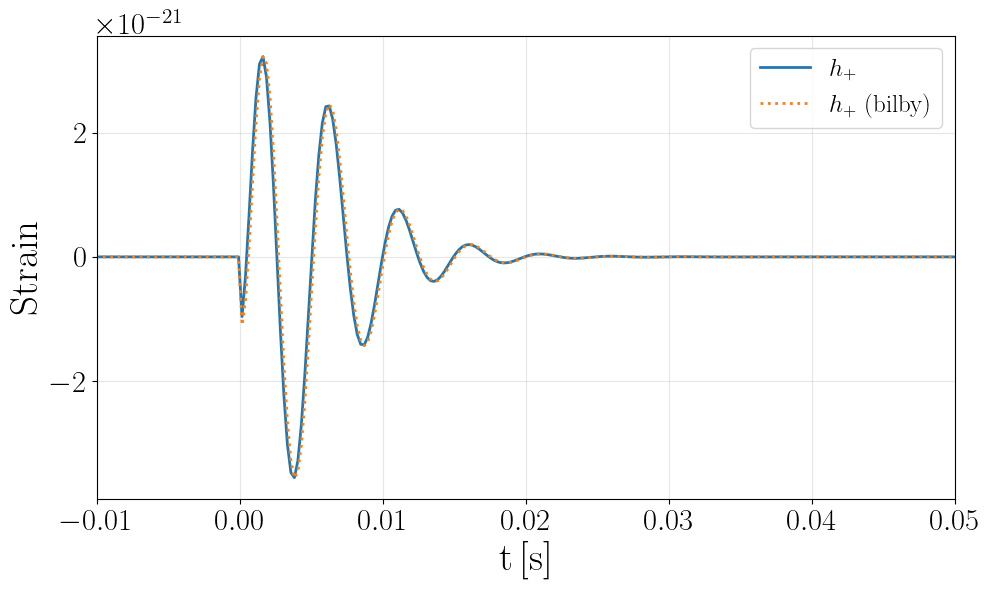

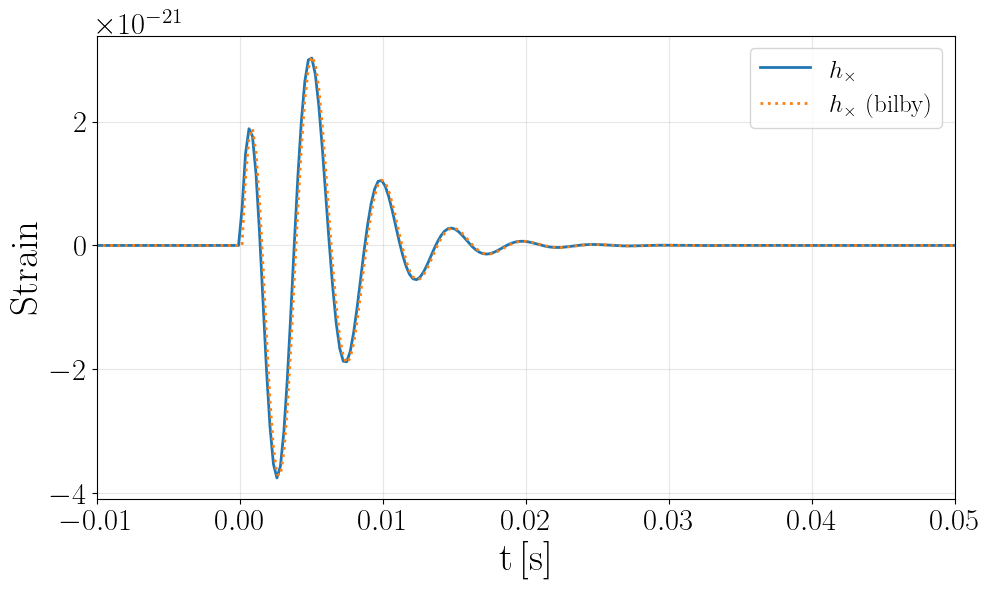

* Injecting the `toy_model_of_two_QNMs_real_amp` waveform model in the H1 detector.
* Injecting the `toy_model_of_two_QNMs_real_amp` waveform model in the L1 detector.
* Injecting the `toy_model_of_two_QNMs_real_amp` waveform model in the V1 detector.


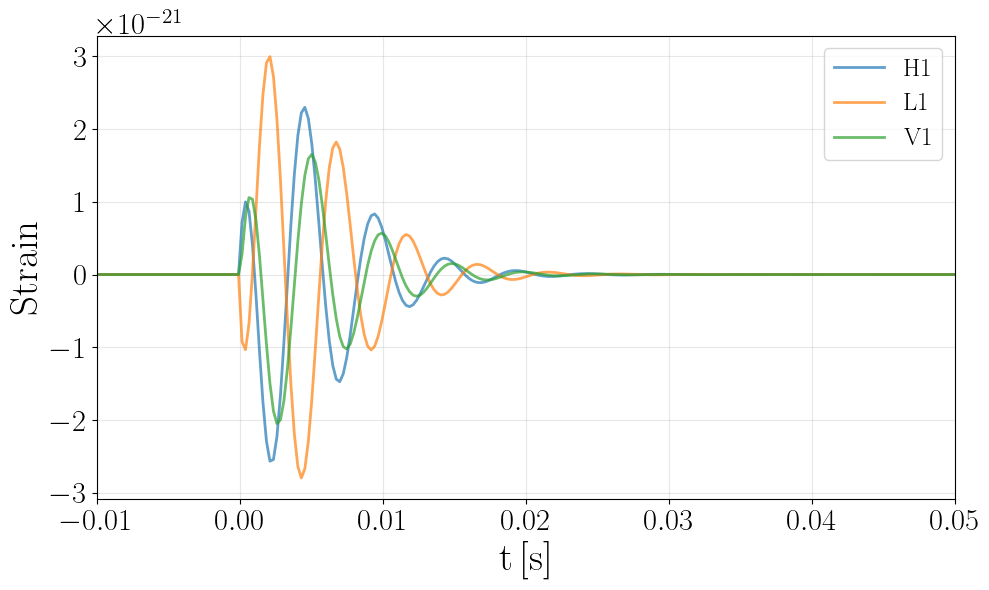

(2049,) (2049,) (2049,)


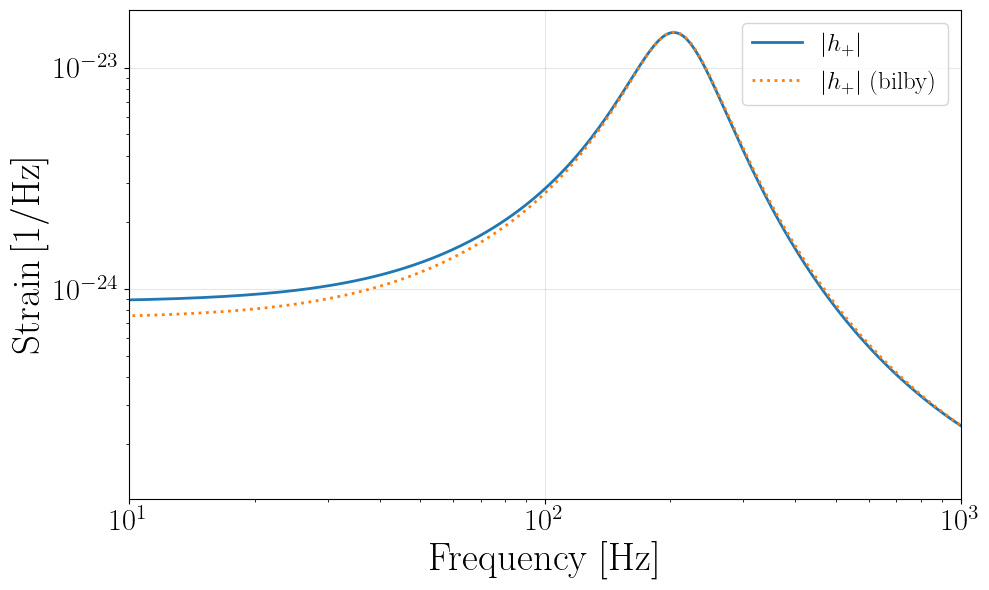

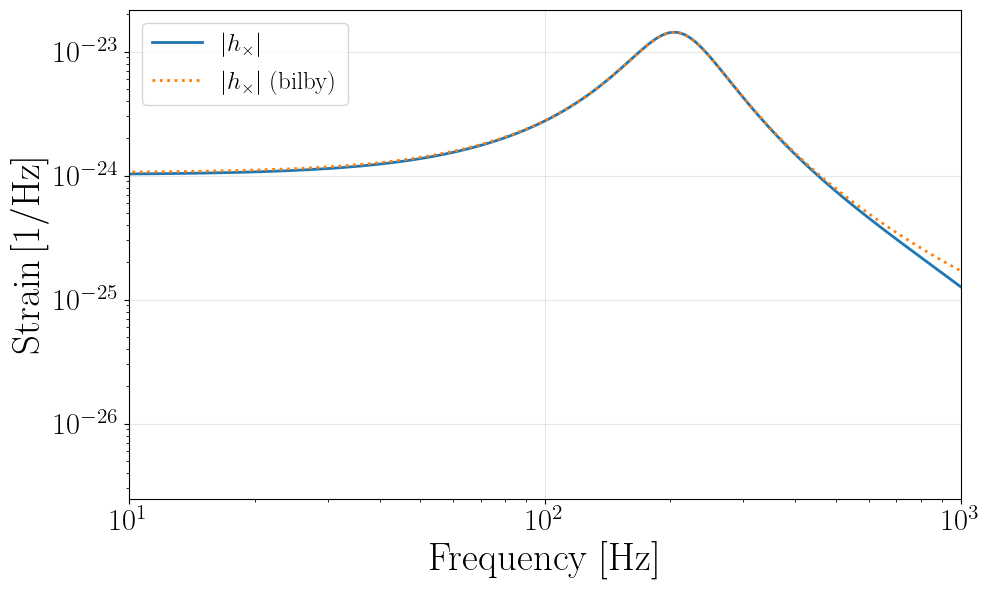

17:15 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
17:15 bilby INFO    : Generation of spin parameters failed with message 'spin_1z'
17:15 bilby INFO    : Generation of source frame parameters failed with message 'luminosity_distance'
17:15 bilby INFO    : Injected signal in H1:
17:15 bilby INFO    :   optimal SNR = 59.48
17:15 bilby INFO    :   matched filter SNR = 59.48-0.00j
17:15 bilby INFO    :   A = 0.371
17:15 bilby INFO    :   alpha = 0.00029552945685847607
17:15 bilby INFO    :   f1 = 201.23779332666524
17:15 bilby INFO    :   f2 = 201.23779332666524
17:15 bilby INFO    :   tau1 = 0.0033219623034593474
17:15 bilby INFO    :   tau2 = 0.0023201731795771175
17:15 bilby INFO    :   phi1 = -1.5707963267948966
17:15 bilby INFO    :   phi2 = 1.6091890156562867
17:15 bilby INFO    :   ra = 0.0
17:15 bilby INFO    :   dec = 0.0
17:15 bilby INFO    :   psi = 0.0
17:15 bilby INFO    :   geocent_time = 0.0
17:15 bilby INFO    : Generation of mass parameters f

--------------------------------
SNR pyring: [59.5168669262501, 70.56857324337678, 38.73043997059853]
network SNR pyring: 100.11107810147152
--------------------------------
--------------------------------
SNR: bilby [59.481355657018014, 70.58581696978273, 38.689534975799106]
network SNR: 100.08630947703047
--------------------------------


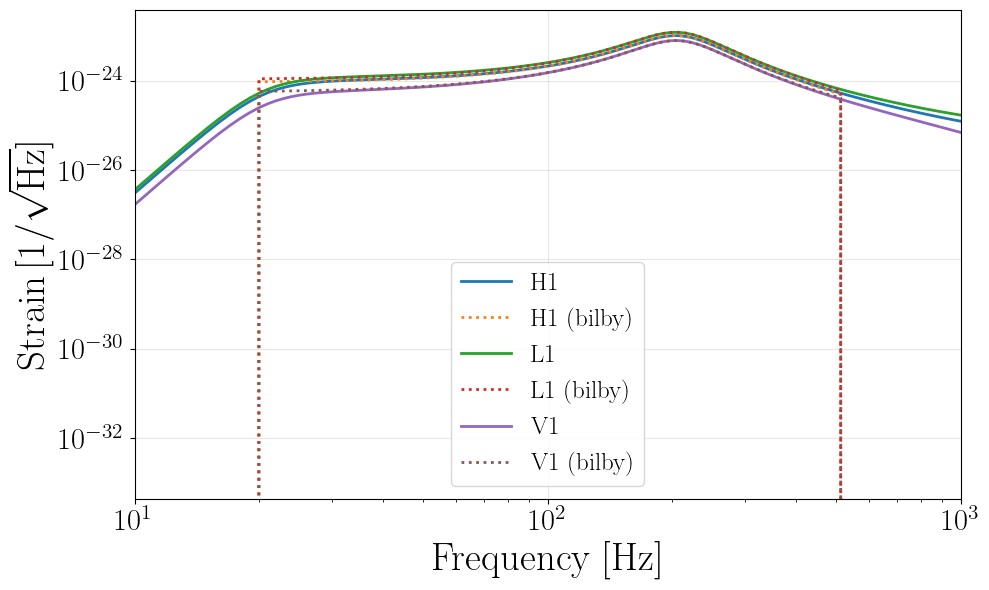


--- Antenna Pattern Check ---
[H1]
  Bilby : F+=-0.3814, Fx=0.5945
  LAL   : F+=-0.3814, Fx=0.5945
[L1]
  Bilby : F+=0.6109, Fx=-0.5707
  LAL   : F+=0.6109, Fx=-0.5707
[V1]
  Bilby : F+=0.0439, Fx=0.5454
  LAL   : F+=0.0439, Fx=0.5454


In [10]:
label = 'shiftIm_to_220_dw0.1w1_snr100_OTparam_real_amp'
# label = 'shiftIm_to_220_dw0.01w1_snr100_OTparam_real_amp'
# label = 'shiftIm_to_220_dw0.001w1_snr100_OTparam_real_amp'
# label = 'shiftRe_to_220_dw0.1w1_snr100_OTparam_real_amp'
# label = 'shiftRe_to_220_dw0.01w1_snr100_OTparam_real_amp'
# label = 'shiftRe_to_220_dw0.001w1_snr100_OTparam_real_amp'

config_file_bilby = f'./run_bilby/config/{label}.ini'
config_file_pyring = f'./run_pyring/config/pyring_{label}.ini'
    
inject_pyring_waveform(config_file_bilby=config_file_bilby, config_file_pyring=config_file_pyring, plot_bilby_waveform=True)
# inject_pyring_waveform(config_file_bilby=config_file_bilby, config_file_pyring=None, plot_bilby_waveform=True)

# EP_waveform

In [ ]:
# Standard python imports
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.interpolate import interp1d
import configparser
from scipy.signal import windows
from scipy.linalg import toeplitz
from scipy.fft import fft, ifft
import os
import errno

# LVC-specific imports
import pyRing.waveform as wf
from pyRing.utils import *
from lalinference.imrtgr.nrutils import *
from pyRing.inject_signal import inject_ringdown_signal
from pyRing.utils import compute_SNR_FD, compute_SNR_TD, project_python_wrapper

from lalinference                import DetFrameToEquatorial, EquatorialToDetFrame
from lalinference.imrtgr.nrutils import bbh_final_mass_projected_spins, bbh_final_spin_projected_spins, bbh_Kerr_trunc_opts
import lal, lalsimulation as lalsim


import bilby
from bilby.core.utils import nfft
from bilby.gw.utils import optimal_snr_squared
from bilby.gw.detector.psd import PowerSpectralDensity
from bilby.core import utils

def toy_model_of_two_QNMs_real_amp(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-17

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1
    
        tidx = time >= geocent_time

        real_amp_1 = np.abs(A / delta_w)
        real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

        waveform1[tidx] = real_amp_1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = real_amp_2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)
        total_waveform = waveform1 + waveform2

        # if one_mode:
            # waveform2 = np.zeros(len(time), dtype=complex)

        # """roll on windowing"""
        # dt = time[1] - time[0]
        # roll_on_samples = int(signal_roll_on_duration / dt)
        # start_index = np.where(tidx)[0][0]
        # taper_end_index = min(start_index + roll_on_samples, len(time))
        # taper_len = taper_end_index - start_index
    
        # hann_taper = windows.hann(2 * taper_len)[:taper_len]
        # total_waveform[start_index:taper_end_index] *= hann_taper
        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = - total_waveform.imag * tukey_window
    
        return {"plus": plus, "cross": cross}
    
def toy_model_of_two_QNMs_real_amp_window(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

    waveform1 = np.zeros(len(time), dtype=complex)
    waveform2 = np.zeros(len(time), dtype=complex)

    A = A * 1e-17

    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)
    delta_w = w2 - w1

    tidx = time >= geocent_time

    real_amp_1 = np.abs(A / delta_w)
    real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

    waveform1[tidx] = real_amp_1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
    waveform2[tidx] = real_amp_2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)
    total_waveform = waveform1 + waveform2

    # if one_mode:
        # waveform2 = np.zeros(len(time), dtype=complex)

    """roll on windowing"""
    dt = time[1] - time[0]
    roll_on_samples = int(signal_roll_on_duration / dt)
    start_index = np.where(tidx)[0][0]
    taper_end_index = min(start_index + roll_on_samples, len(time))
    taper_len = taper_end_index - start_index

    hann_taper = windows.hann(2 * taper_len)[:taper_len]
    total_waveform[start_index:taper_end_index] *= hann_taper
    """segment windowing"""
    tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
    plus = total_waveform.real * tukey_window
    cross = - total_waveform.imag * tukey_window

    return {"plus": plus, "cross": cross}

def toy_model_of_two_QNMs_real_amp_tdomain_mirror(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

    A = A * 1e-17 / 2**0.5

    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)
    delta_w = w2 - w1

    real_amp_1 = np.abs(A / delta_w)
    real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

    waveform1 = real_amp_1 * np.exp(1j * (2 * np.pi * f1 * (time - geocent_time))) * np.exp(- np.abs((time - geocent_time) / tau1)) * np.exp(1j * phi1)
    waveform2 = real_amp_2 * np.exp(1j * (2 * np.pi * f2 * (time - geocent_time))) * np.exp(- np.abs((time - geocent_time) / tau2)) * np.exp(1j * phi2)
    total_waveform = waveform1 + waveform2

    # if one_mode:
        # waveform2 = np.zeros(len(time), dtype=complex)

    """segment windowing"""
    tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
    plus = total_waveform.real * tukey_window
    cross = - total_waveform.imag * tukey_window

    return {"plus": plus, "cross": cross}

def toy_model_of_two_QNMs_real_amp_fdomain_mirror(frequency, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time):
    A = A * 1e-17
    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)
    delta_w = w2 - w1

    real_amp_1 = np.abs(A / delta_w) / 2**0.5
    real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha)) / 2**0.5

    d_positive_1 = (1 / tau1)**2 + (2 * (frequency + f1) * np.pi)**2
    d_negative_1 = (1 / tau1)**2 + (2 * (frequency - f1) * np.pi)**2
    d_positive_2 = (1 / tau2)**2 + (2 * (frequency + f2) * np.pi)**2
    d_negative_2 = (1 / tau2)**2 + (2 * (frequency - f2) * np.pi)**2

    plus = real_amp_1 / tau1  * (np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1) + real_amp_2 / tau2 * (np.exp(-1j * phi2) / d_positive_2 + np.exp(1j * phi2) / d_negative_2)
    cross = 1j * (real_amp_1 / tau1 * (np.exp(-1j * phi1) / d_positive_1 - np.exp(1j * phi1) / d_negative_1) + real_amp_2 / tau2 * (np.exp(-1j * phi2) / d_positive_2 - np.exp(1j * phi2) / d_negative_2))
    
    return {'plus': plus, 'cross': cross}

def toy_model_of_two_QNMs_real_amp_fdomain_Heaviside(frequency, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time):
    A = A * 1e-17
    w1 = (2*np.pi*f1 + 1j / tau1)
    w2 = (2*np.pi*f2 + 1j / tau2)
    delta_w = w2 - w1

    real_amp_1 = np.abs(A / delta_w)
    real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

    d_positive_1 = (-1j / tau1) + (2 * (frequency + f1) * np.pi)
    d_negative_1 = (-1j / tau1) + (2 * (frequency - f1) * np.pi)

    d_positive_2 = (-1j / tau2) + (2 * (frequency + f2) * np.pi)
    d_negative_2 = (-1j / tau2) + (2 * (frequency - f2) * np.pi)
    
    plus = real_amp_1 * ((-1/tau1 - 1j*2*np.pi*frequency) * np.cos(phi1) + 2*np.pi*f1*np.sin(phi1)) / (d_positive_1 * d_negative_1) + real_amp_2 * ((-1/tau2 - 1j*2*np.pi*frequency) * np.cos(phi2) + 2*np.pi*f2*np.sin(phi2)) / (d_positive_2 * d_negative_2)
    cross = -real_amp_1 * (2*np.pi*f1*np.cos(phi1) + (1/tau1 + 1j*2*np.pi*frequency) * np.sin(phi1)) / (d_positive_1 * d_negative_1) - real_amp_2 * (2*np.pi*f2*np.cos(phi2) + (1/tau2 + 1j*2*np.pi*frequency) * np.sin(phi2)) / (d_positive_2 * d_negative_2)

    return {'plus': plus, 'cross': cross}

def EP_waveform_tdomain_Mirror(time, A, alpha, f, tau, geocent_time):
    waveform = np.zeros(len(time), dtype=complex)

    A = A * 1e-17
    w_ep = (2 * np.pi * f + 1j / tau)

    waveform = - (1/np.sqrt(2)) * (A*alpha + 1j*A*np.abs(time - geocent_time)) * np.exp(1j * (2 * np.pi * f * (time - geocent_time))) * np.exp(- np.abs(time - geocent_time) / tau)

    plus = waveform.real
    cross = - waveform.imag

    tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
    plus *= tukey_window
    cross *= tukey_window

    return {"plus": plus, "cross": cross}

def EP_waveform_tdomain_Heaviside(time, A, alpha, f, tau, geocent_time):
    waveform = np.zeros(len(time), dtype=complex)

    A = A * 1e-17
    w_ep = (2 * np.pi * f + 1j / tau)

    tidix = time >= geocent_time
    waveform[tidix] = - (A*alpha + 1j*A*(time[tidix] - geocent_time)) * np.exp(1j * (2 * np.pi * f * (time[tidix] - geocent_time))) * np.exp(- np.abs(time[tidix] - geocent_time) / tau)

    plus = waveform.real
    cross = - waveform.imag

    # tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
    # plus *= tukey_window
    # cross *= tukey_window

    return {"plus": plus, "cross": cross}

def compute_covariance_matrix_from_psd(psd, srate, signal_duration):
    dt = 1.0 / srate
    noise_seglen = int(1 * srate)
    signal_seglen = int(signal_duration * srate)
    freqs_from_file, psd_from_file = psd[:,0], psd[:,1]

    f_min_psd = 20.5
    f_max_psd = 2038.0

    psd_from_file   = psd_from_file[  freqs_from_file > f_min_psd]
    freqs_from_file = freqs_from_file[freqs_from_file > f_min_psd]
    psd_from_file   = psd_from_file[  freqs_from_file < f_max_psd]
    freqs_from_file = freqs_from_file[freqs_from_file < f_max_psd]

    psd_from_file_interp           = interp1d(freqs_from_file, psd_from_file, fill_value='extrapolate', bounds_error=False)
    freqs_default                  = np.fft.rfftfreq(noise_seglen, d = dt)
    df_default                     = np.diff(freqs_default)[0]
    psd_interp                     = psd_from_file_interp(freqs_default)
    psd_interp                     = np.abs(psd_interp)

    ACF = 0.5*np.real(np.fft.irfft(psd_interp*df_default))*noise_seglen
    ACF_signal = ACF[:signal_seglen]
    Covariance_matrix_signal = toeplitz(ACF_signal)
    epsilon = 1e-9 * np.max(np.diag(Covariance_matrix_signal))
    Covariance_matrix_signal += epsilon * np.eye(signal_seglen)
    return Covariance_matrix_signal

def inject_pyring_waveform(config_file_bilby, config_file_pyring=None, plot_bilby_waveform=False):

    if config_file_pyring is not None:
        config_ini_pyring = configparser.ConfigParser()
        config_ini_pyring.read(config_file_pyring)
        if not os.path.exists(config_file_pyring):
            raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), config_file_pyring)
        config_injection_pyring = config_ini_pyring['Injection']
    
    config_ini_bilby = configparser.ConfigParser()
    config_ini_bilby.read(config_file_bilby)
    if not os.path.exists(config_file_bilby):
        raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), config_file_bilby)
    config_injection_bilby = config_ini_bilby['injection_parameters']
    config_injection_bilby['tau1'] = str(np.abs(float(config_injection_bilby['tau1'])))
    config_injection_bilby['tau2'] = str(np.abs(float(config_injection_bilby['tau2'])))
    
    config_setting = config_ini_bilby['setting']
    mode_number = config_setting['mode_number']

    srate   = 4096
    # signal_duration = 410 / srate
    signal_duration = 1.0
    pre_trigger_duration = signal_duration / 2.0
    trigger_time = float(config_injection_bilby['geocent_time'])
    times   = np.linspace(trigger_time-pre_trigger_duration, trigger_time+signal_duration-pre_trigger_duration, int(srate*signal_duration))

    A = float(config_injection_bilby['A']) * 1e-20  # Convert to strain unit
    alpha = float(config_injection_bilby['alpha'])
    w1 = (2 * np.pi * float(config_injection_bilby['f1']) + 1j / float(config_injection_bilby['tau1']))
    w2 = (2 * np.pi * float(config_injection_bilby['f2']) + 1j / float(config_injection_bilby['tau2']))
    delta_w = w2 - w1
    A1_complex = A / delta_w
    A1 = np.abs(A1_complex) / 1e-20
    phi1_from_amp = np.angle(A1_complex)
    phi1 = float(config_injection_bilby['phi1']) + phi1_from_amp
    A2_complex = - A * (1 + alpha * delta_w) / delta_w
    A2 = np.abs(A2_complex) / 1e-20
    phi2_from_amp = np.angle(A2_complex)
    phi2 = float(config_injection_bilby['phi2']) + phi2_from_amp

    bilby.core.utils.logger.info('A1 : {} * 1e-20'.format(A1))
    bilby.core.utils.logger.info('A2 : {} * 1e-20'.format(A2))
    bilby.core.utils.logger.info('alpha : {}'.format(alpha))
    bilby.core.utils.logger.info('w1 : {}'.format(w1))
    bilby.core.utils.logger.info('w2 : {}'.format(w2))
    bilby.core.utils.logger.info('delta_w : {}'.format(delta_w))
    bilby.core.utils.logger.info('delta_w * alpha : {}'.format(delta_w * alpha))
    bilby.core.utils.logger.info('phi1 : {}'.format(phi1))
    bilby.core.utils.logger.info('phi2 : {}'.format(phi2))


    if config_file_pyring is None:
        C = - A * alpha
        D = - A
        f1 = float(config_injection_bilby['f2'])
        tau1 = float(config_injection_bilby['tau2'])
        parameters = {
                    'C'     : C,
                    'D'     : D,
                    'f'   : f1,
                    'tau' : tau1,
                    'psi' : float(config_injection_bilby['psi']),
                    'ra'  : float(config_injection_bilby['ra']),
                    'dec' : float(config_injection_bilby['dec']),
                    't'   : float(config_injection_bilby['geocent_time']),
                     }
    else:
        parameters = {
                    'C'     : float(config_injection_pyring['C']),
                    'D' : float(config_injection_pyring['D']),
                    'f'    : float(config_injection_pyring['f1']),
                    'tau' : float(config_injection_pyring['tau1']),
                    'psi' : float(config_injection_pyring['psi']),
                    'ra'  : float(config_injection_pyring['ra']),
                    'dec' : float(config_injection_pyring['dec']),
                    't'   : float(config_injection_pyring['t']),
                             }
    print('--- Injection toy_model_two_QNMs_real_amp Parameters ---')
    print('[Injection]')
    for key in parameters.keys():
        if isinstance(parameters[key], dict):
            for mode in parameters[key].keys():
                val_list = np.array(parameters[key][mode])
                for num, val in enumerate(val_list):
                    print(f"{key}_{mode}_{num} = {val}")
        else:
            print(f"{key} = {parameters[key]}")
    print('-------------------------------------------')
    model = wf.EP_waveform(
                        parameters['C']  ,
                        parameters['D']  ,
                        parameters['f']  ,
                        parameters['tau'],
                        parameters['t'],
                        )

    # Unpack the waveform and ignore vector and scalar modes.
    _, _, _, hp_DS, hc_DS = model.waveform(times)

    if plot_bilby_waveform:
        if mode_number == 'one_mode':
            A2 = 0.0
        injection_parameters_bilby = dict(
                                    A = float(config_injection_bilby['A']) * 1e-3,
                                    alpha = float(config_injection_bilby['alpha']),
                                    f1 = float(config_injection_bilby['f1']),
                                    f2 = float(config_injection_bilby['f2']),
                                    tau1 = float(config_injection_bilby['tau1']),
                                    tau2 = float(config_injection_bilby['tau2']),
                                    phi1 = phi1,
                                    phi2 = phi2,
                                    ra = float(config_injection_bilby['ra']),
                                    dec = float(config_injection_bilby['dec']),
                                    psi = float(config_injection_bilby['psi']),
                                    geocent_time = float(config_injection_bilby['geocent_time']),
                                    )
        # injection_parameters_bilby = dict(
        #                             A = float(config_injection_bilby['A']) * 1e-3,
        #                             alpha = float(config_injection_bilby['alpha']),
        #                             f = float(config_injection_bilby['f2']),
        #                             tau = float(config_injection_bilby['tau2']),
        #                             ra = float(config_injection_bilby['ra']),
        #                             dec = float(config_injection_bilby['dec']),
        #                             psi = float(config_injection_bilby['psi']),
        #                             geocent_time = float(config_injection_bilby['geocent_time']),
        #                             )
        waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                        duration = signal_duration,
                                        sampling_frequency = srate,
                                        time_domain_source_model = toy_model_of_two_QNMs_real_amp,
                                        # time_domain_source_model = EP_waveform_tdomain_Heaviside,
                                        start_time = trigger_time - pre_trigger_duration,
                                        )

    plt.style.use('~/research/my_plot_style.style')
    # plt.title(r'$\mathrm{Damped \, sinusoids}$')
    if plot_bilby_waveform:
        ht_bilby = waveform_generator.time_domain_strain(injection_parameters_bilby)

        plt.figure()
        plt.plot(times, hp_DS, label=r'$h_{+}$', linestyle='-')
        plt.plot(times, ht_bilby['plus'], label=r'$h_{+}$ (bilby)', linestyle=':')
        plt.xlabel(r'$\mathrm{t \, [s]}$')
        plt.ylabel(r'$\mathrm{Strain}$')
        plt.xlim(-0.01, 0.05)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure()        
        plt.plot(times, hc_DS, label=r'$h_{\times}$', linestyle='-')
        plt.plot(times, ht_bilby['cross'], label=r'$h_{\times}$ (bilby)', linestyle=':')
        plt.xlabel(r'$\mathrm{t \, [s]}$')
        plt.ylabel(r'$\mathrm{Strain}$')
        plt.xlim(-0.01, 0.05)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()
    
    else:
        plt.figure()
        plt.plot(times, hp_DS, label=r'$\mathrm{h}_{+}$', linestyle='-')
        plt.plot(times, hc_DS, label=r'$\mathrm{h}_{\times}$', linestyle='-')
        plt.xlabel(r'$\mathrm{t \, [s]}$')
        plt.ylabel(r'$\mathrm{Strain}$')
        plt.xlim(-0.01, 0.05)
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

    detectors = ['H1', 'L1', 'V1']

    plt.figure()
    # plt.title(r'$\mathrm{Injected \, Damped \, sinusoids}$')
    detector_wave_dicts = {}
    for detector in detectors:
        kwargs = {
            'injection-approximant' : 'EP_waveform',
            'injection-parameters' : parameters,
            'ref-det' : detector,
            'sky-frame' : 'equatorial',
            'injection-scaling' : 1.0,
        }
        wave, time_axis_waveform = inject_ringdown_signal(times=times, triggertime=trigger_time, ifo=detector, print_output=True, **kwargs)
        plt.plot(time_axis_waveform, wave, linestyle='solid', alpha=0.7, label=detector)
        detector_wave_dicts[detector] = {'waveform': wave, 'time_axis': time_axis_waveform}
    plt.xlabel(r'$\mathrm{t \, [s]}$')
    plt.ylabel(r'$\mathrm{Strain}$')
    plt.xlim(-0.01, 0.05)
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

    """calculate frequency domain strain"""
    ifos = bilby.gw.detector.InterferometerList(detectors)
    h_plus_fdomain, frequency_array = nfft(time_domain_strain=hp_DS, sampling_frequency=srate)
    h_cross_fdomain, frequency_array = nfft(time_domain_strain=hc_DS, sampling_frequency=srate)
    print(frequency_array.shape, h_plus_fdomain.shape, h_cross_fdomain.shape)

    if plot_bilby_waveform:
        hf_bilby = waveform_generator.frequency_domain_strain(injection_parameters_bilby)

        plt.figure()
        plt.plot(frequency_array, np.abs(h_plus_fdomain), label=r'$|h_{+}|$', linestyle='-')
        plt.plot(frequency_array, np.abs(hf_bilby['plus']), label=r'$|h_{+}|$ (bilby)', linestyle=':')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure()
        plt.plot(frequency_array, np.abs(h_cross_fdomain), label=r'$|h_{\times}|$', linestyle='-')
        plt.plot(frequency_array, np.abs(hf_bilby['cross']), label=r'$|h_{\times}|$ (bilby)', linestyle=':')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()

        # plt.figure()
        # plt.plot(frequency_array, np.real(h_plus_fdomain), label=r'Re[$h_{+}$]', linestyle='-')
        # plt.plot(frequency_array, np.real(hf_bilby['plus']), label=r'Re[$h_{+}$] (bilby)', linestyle=':')
        # plt.xlim(10, 1000)
        # plt.xscale('log')
        # plt.xlabel('Frequency [Hz]')
        # plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        # plt.legend(loc='best')
        # plt.grid(alpha=0.3)
        # plt.show()

        # plt.figure()
        # plt.plot(frequency_array, np.real(h_cross_fdomain), label=r'Re[$h_{\times}$]', linestyle='-')
        # plt.plot(frequency_array, np.real(hf_bilby['cross']), label=r'Re[$h_{\times}$] (bilby)', linestyle=':')
        # plt.xlim(10, 1000)
        # plt.xscale('log')
        # plt.xlabel('Frequency [Hz]')
        # plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        # plt.legend(loc='best')
        # plt.grid(alpha=0.3)
        # plt.show()

    else:
        plt.figure()
        plt.plot(frequency_array, np.abs(h_plus_fdomain), label=r'$|h_{+}|$', color='crimson', linestyle='dashed')
        plt.plot(frequency_array, np.abs(h_cross_fdomain), label=r'$|h_{\times}|$', color='royalblue', linestyle='solid')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\mathrm{Hz}]$')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.show()
    
    """calculate frequency domain response and SNR"""
    for ifo in ifos:
        ifo.frequency_array = frequency_array
        ifo.minimum_frequency = 20.0
        ifo.maximum_frequency = 512
    

    psd_ligo = './asd_files/aLIGO_O4_high_psd.txt'
    psd_virgo = './asd_files/AdV_psd.txt'

    psd = {}
    psd['H1'] = np.loadtxt(psd_ligo)
    psd['L1'] = np.loadtxt(psd_ligo)
    psd['V1'] = np.loadtxt(psd_virgo)

    parameters['geocent_time'] = float(config_injection_bilby['geocent_time'])

    SNR_pyring = []
    ht_dict_pyring = {}
    for name, ifo in zip(detectors, ifos):
        
        detector = lal.cached_detector_by_prefix[ifo.name]
        ref_det    = lal.cached_detector_by_prefix['H1']
        psi        = parameters['psi']
        ra, dec    = parameters['ra'], parameters['dec']
        tM_gps     = lal.LIGOTimeGPS(float(parameters['geocent_time']))
        time_delay = lal.ArrivalTimeDiff(detector.location, ref_det.location, ra, dec, tM_gps)

        ht_det = project_python_wrapper(hs=0,
                                        hvx=0, hvy=0,
                                        hp=hp_DS,
                                        hc=hc_DS,
                                        detector=detector,
                                        ra=parameters['ra'],
                                        dec=parameters['dec'],
                                        psi=parameters['psi'],
                                        tgps=parameters['geocent_time']
                                        )
        
        f_min_bp = 20.5
        f_max_bp = 2038.0
        bb, ab = butter(4, [f_min_bp / (srate / 2.), f_max_bp / (srate / 2.)], btype='band')
        
        ht_det_filtered = filtfilt(bb, ab, ht_det)
        ht_dict_pyring[ifo.name] = ht_det_filtered

        CM = compute_covariance_matrix_from_psd(psd[ifo.name], srate, signal_duration)
        inverse_CM = np.linalg.inv(CM)
        SNR = compute_SNR_TD(data=ht_det_filtered, template=ht_det_filtered, weights=inverse_CM)
        SNR_pyring.append(SNR)

    network_SNR = np.sqrt(np.sum(np.array(SNR_pyring)**2.))
    print('--------------------------------')
    print('SNR pyring: {}'.format(SNR_pyring))
    print('network SNR pyring: {}'.format(network_SNR))
    print('--------------------------------')

    # should be fd waveform for pyring using fft
    detector_wave_fdomain_dicts = {}
    for name, ifo in zip(detectors, ifos):
        hf_det, frequency_array = nfft(time_domain_strain=ht_dict_pyring[ifo.name], sampling_frequency=srate)
        detector_wave_fdomain_dicts[ifo.name] = {'waveform': hf_det, 'frequency_array': frequency_array}
        
    if plot_bilby_waveform:
        ifos_bilby = bilby.gw.detector.InterferometerList(detectors)
        ifos_bilby.set_strain_data_from_zero_noise(
                               sampling_frequency = srate,
                               duration = signal_duration,
                               start_time = trigger_time - pre_trigger_duration,
                               )
        for ifo_bilby, ifo in zip(ifos_bilby, ifos):
            ifo_bilby.minimum_frequency = ifo.minimum_frequency
            ifo_bilby.maximum_frequency = ifo.maximum_frequency

        ifos_bilby.inject_signal(
            waveform_generator = waveform_generator,
            parameters = injection_parameters_bilby,
            raise_error=False,
        )
        SNR_bilby = []
        for num, ifo in enumerate(ifos_bilby):
            hf_det_bilby = ifo.get_detector_response(waveform_generator.frequency_domain_strain(injection_parameters_bilby), injection_parameters_bilby)
            SNR_bilby.append(np.sqrt(np.real(ifo.optimal_snr_squared(hf_det_bilby))))
    network_SNR_bilby = np.sqrt(np.sum(np.array(SNR_bilby)**2.))
    print('--------------------------------')
    print('SNR: bilby {}'.format(SNR_bilby))
    print('network SNR: {}'.format(network_SNR_bilby))
    print('--------------------------------')
    
    if plot_bilby_waveform:
        plt.figure()
        for ifo, ifo_bilby in zip(ifos, ifos_bilby):
            plt.plot(ifo.frequency_array, np.abs(detector_wave_fdomain_dicts[ifo.name]['waveform']), label=ifo.name)
            plt.plot(ifo_bilby.frequency_array, np.abs(ifo_bilby.frequency_domain_strain), linestyle=':', label=ifo.name + ' (bilby)')
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\sqrt{\mathrm{Hz}}]$')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
    else:
        plt.figure()
        for ifo in ifos:
            plt.plot(detector_wave_fdomain_dicts[ifo.name]['frequency_array'], 2*detector_wave_fdomain_dicts[ifo.name]['frequency_array']**0.5*np.abs(detector_wave_fdomain_dicts[ifo.name]['waveform']), label=ifo.name)
        plt.xlim(10, 1000)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel(r'$\mathrm{Strain} \, [1/\sqrt{\mathrm{Hz}}]$')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # --- デバッグ用コード追加 ---
    print("\n--- Antenna Pattern Check ---")
    gps_time = float(parameters['geocent_time'])
    ra = parameters['ra']
    dec = parameters['dec']
    psi = parameters['psi']
    for name, ifo in zip(detectors, ifos):
        # Bilbyの計算値
        fp_bilby, fc_bilby = ifo.antenna_response(ra, dec, gps_time, psi, mode='plus'), \
                             ifo.antenna_response(ra, dec, gps_time, psi, mode='cross')
    
        # 簡易的なLAL計算（project_python_wrapperの内部動作確認用）
        # 注: project_python_wrapperがGMSTを内部でどう扱っているかに依存します
        det_lal = lal.cached_detector_by_prefix[name]
        gmst = lal.GreenwichMeanSiderealTime(lal.LIGOTimeGPS(gps_time))
        fp_lal, fc_lal = lal.ComputeDetAMResponse(det_lal.response, ra, dec, psi, gmst)
    
        print(f"[{name}]")
        print(f"  Bilby : F+={fp_bilby:.4f}, Fx={fc_bilby:.4f}")
        print(f"  LAL   : F+={fp_lal:.4f}, Fx={fc_lal:.4f}")

17:17 bilby INFO    : A1 : 2.281200654005359 * 1e-20
17:17 bilby INFO    : A2 : 2.193576170046821 * 1e-20
17:17 bilby INFO    : alpha : 0.00029552945685847607
17:17 bilby INFO    : w1 : (1264.4143462793452+301.02689574732483j)
17:17 bilby INFO    : w2 : (1134.4389320257144+301.02689574732483j)
17:17 bilby INFO    : delta_w : (-129.9754142536308+0j)
17:17 bilby INFO    : delta_w * alpha : (-0.03841156357933093+0j)
17:17 bilby INFO    : phi1 : -3.141592653589793
17:17 bilby INFO    : phi2 : 0.0
17:17 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1.0, sampling_frequency=4096, start_time=-0.5, frequency_domain_source_model=None, time_domain_source_model=__main__.toy_model_of_two_QNMs_real_amp, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={})


--- Injection toy_model_two_QNMs_real_amp Parameters ---
[Injection]
A = 2.965e-18
alpha = 0.00029552945685847607
f1 = 201.23779332666524
f2 = 180.55156366778309
tau1 = 0.0033219623034593474
tau2 = 0.0033219623034593474
phi1 = -3.141592653589793
phi2 = 0.0
psi = 0.0
ra = 0.0
dec = 0.0
t = 0.0
-------------------------------------------


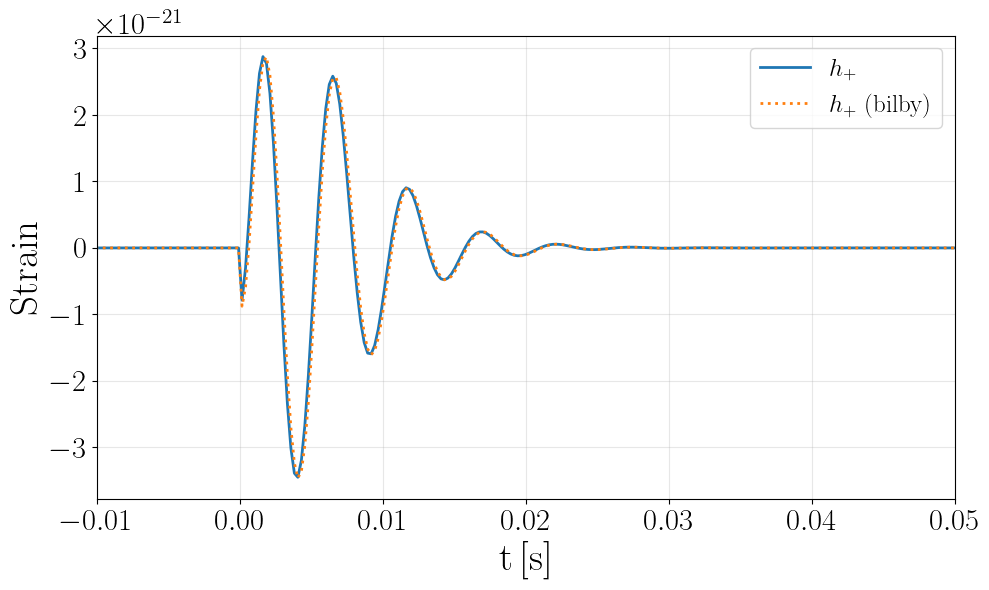

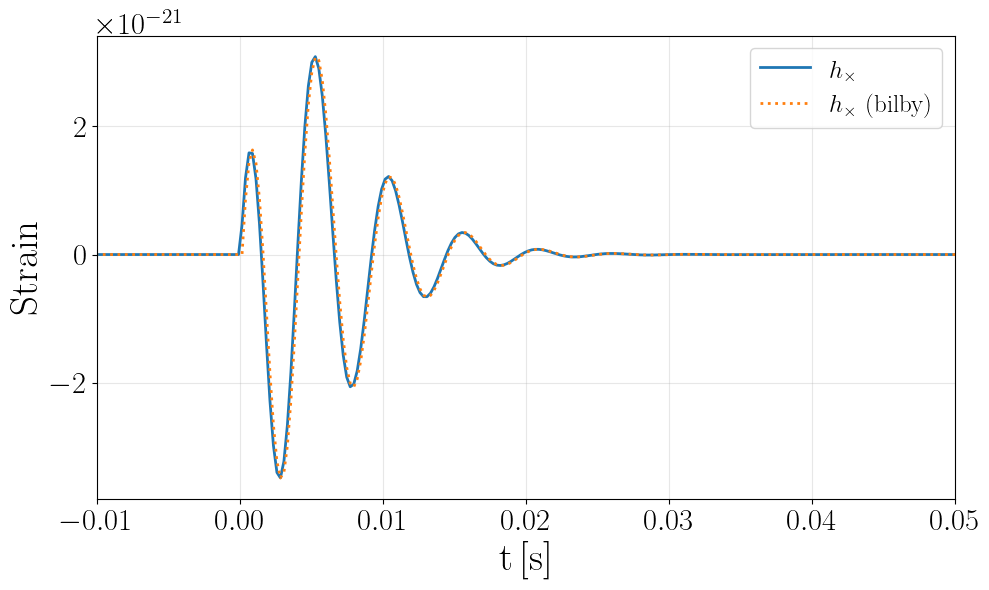

* Injecting the `toy_model_of_two_QNMs_real_amp` waveform model in the H1 detector.
* Injecting the `toy_model_of_two_QNMs_real_amp` waveform model in the L1 detector.
* Injecting the `toy_model_of_two_QNMs_real_amp` waveform model in the V1 detector.


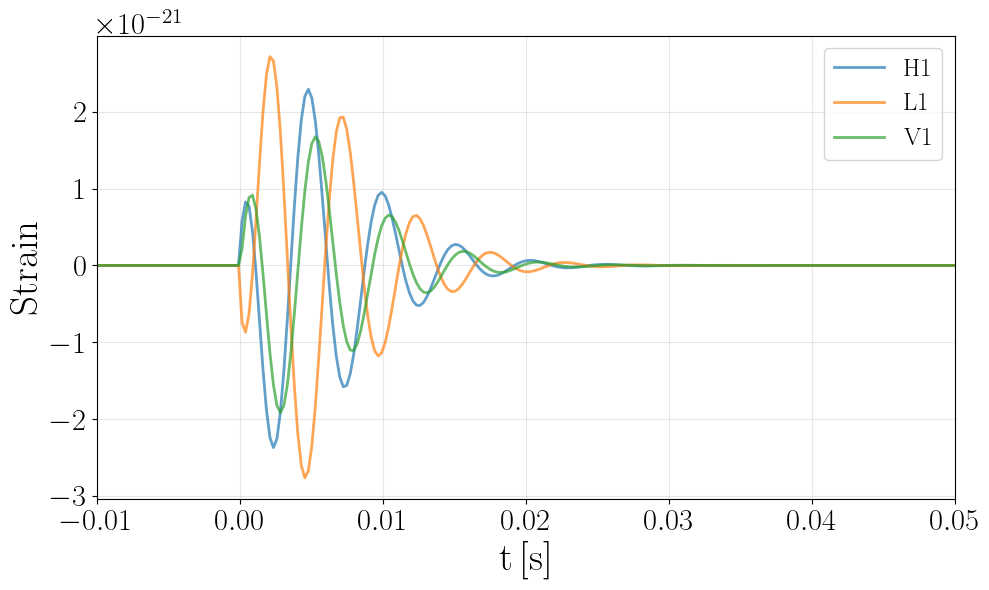

(2049,) (2049,) (2049,)


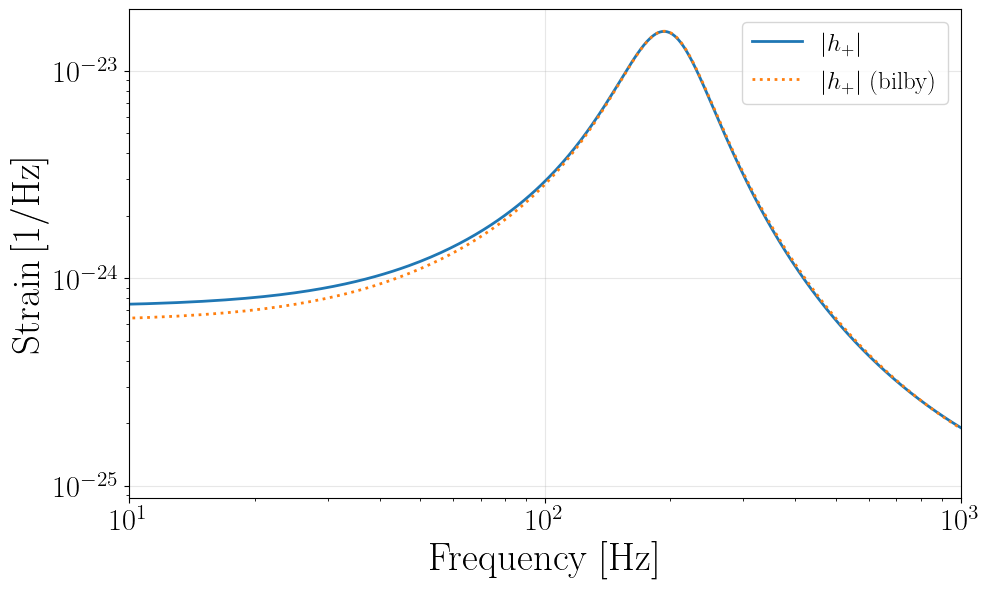

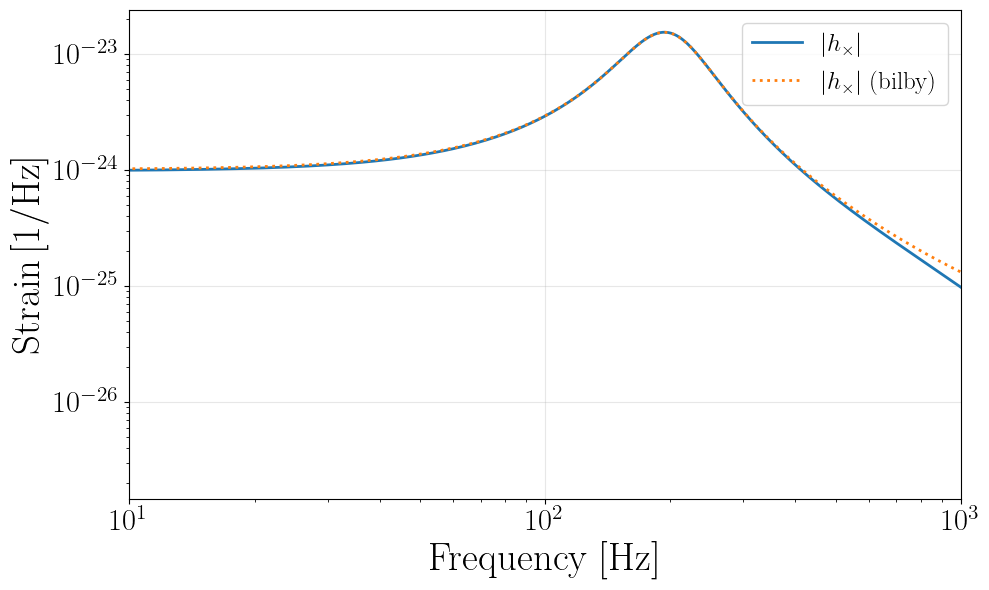

17:17 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
17:17 bilby INFO    : Generation of spin parameters failed with message 'spin_1z'
17:17 bilby INFO    : Generation of source frame parameters failed with message 'luminosity_distance'
17:17 bilby INFO    : Injected signal in H1:
17:17 bilby INFO    :   optimal SNR = 59.56
17:17 bilby INFO    :   matched filter SNR = 59.56+0.00j
17:17 bilby INFO    :   A = 0.2965
17:17 bilby INFO    :   alpha = 0.00029552945685847607
17:17 bilby INFO    :   f1 = 201.23779332666524
17:17 bilby INFO    :   f2 = 180.55156366778309
17:17 bilby INFO    :   tau1 = 0.0033219623034593474
17:17 bilby INFO    :   tau2 = 0.0033219623034593474
17:17 bilby INFO    :   phi1 = -3.141592653589793
17:17 bilby INFO    :   phi2 = 0.0
17:17 bilby INFO    :   ra = 0.0
17:17 bilby INFO    :   dec = 0.0
17:17 bilby INFO    :   psi = 0.0
17:17 bilby INFO    :   geocent_time = 0.0
17:17 bilby INFO    : Generation of mass parameters failed with mess

--------------------------------
SNR pyring: [59.57327841620506, 70.60596093561007, 38.46355513964454]
network SNR pyring: 100.06808829430118
--------------------------------
--------------------------------
SNR: bilby [59.55835049301124, 70.6281192872069, 38.44223681072555]
network SNR: 100.0666473831726
--------------------------------


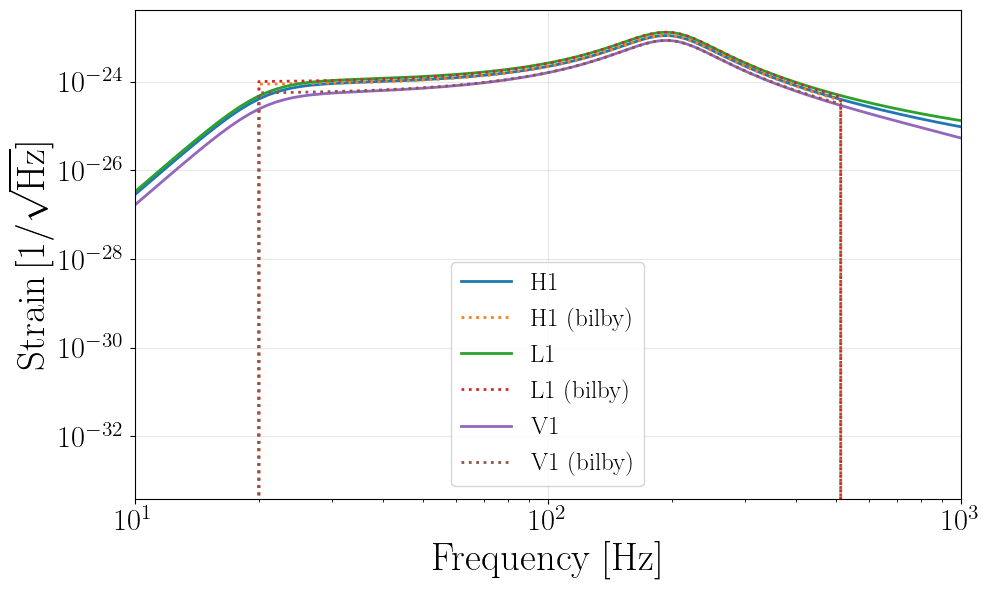


--- Antenna Pattern Check ---
[H1]
  Bilby : F+=-0.3814, Fx=0.5945
  LAL   : F+=-0.3814, Fx=0.5945
[L1]
  Bilby : F+=0.6109, Fx=-0.5707
  LAL   : F+=0.6109, Fx=-0.5707
[V1]
  Bilby : F+=0.0439, Fx=0.5454
  LAL   : F+=0.0439, Fx=0.5454


In [12]:
# label = 'shiftIm_to_220_dw0.1w1_snr100_EPparam_Heaviside'
# label = 'shiftIm_to_220_dw0.01w1_snr100_EPparam_Heaviside'
# label = 'shiftIm_to_220_dw0.001w1_snr100_EPparam_Heaviside'
label = 'shiftRe_to_220_dw0.1w1_snr100_EPparam_Heaviside'
# label = 'shiftRe_to_220_dw0.01w1_snr100_EPparam_Heaviside'
# label = 'shiftRe_to_220_dw0.001w1_snr100_EPparam_Heaviside'

config_file_bilby = f'./run_bilby/config/{label}.ini'
# config_file_pyring = f'./run_pyring/config/pyring_{label}.ini'

# inject_pyring_waveform(config_file_bilby=config_file_bilby, config_file_pyring=config_file_pyring, plot_bilby_waveform=True)
inject_pyring_waveform(config_file_bilby=config_file_bilby, config_file_pyring=None, plot_bilby_waveform=True)